# 🔥 Calories Burned Prediction — Optuna + XGB/LGB/CAT Ensemble

| 항목 | 내용 |
|---|---|
| **환경** | Google Colab (GPU T4/A100 권장) |
| **모델** | XGBoost · LightGBM · CatBoost |
| **HP 최적화** | **Optuna** (TPE Sampler + MedianPruner) |
| **앙상블** | 개별 Optuna 최적화 → KFold CV → **Optuna 가중치 최적화** |
| **이전 결과** | CAT=1.1244 · XGB=1.3836 · LGB=1.5103 · 제출 RMSE=0.80 |
| **목표** | 제출 RMSE **0.80 이하** |

### 🚀 RMSE 개선 전략
1. **피처 엔지니어링 강화** — BMR, 열부하, 대사스트레스, 3-way 교차항
2. **Optuna (TPE) 탐색 범위를 이전 최적값 근방으로 집중** — 더 빠르고 정밀한 수렴
3. **앙상블 가중치도 Optuna로 최적화** — 단순 평균 대비 추가 RMSE 감소
4. **Early Stopping + MedianPruner** — 가망 없는 trial 즉시 종료로 시간 절약

## ⚙️ 0. Colab 환경 설정 & 패키지 설치

In [ ]:
# ── Colab GPU 체크
import subprocess, sys

try:
    gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if 'failed' in gpu_info.stdout.lower() or gpu_info.returncode != 0:
        print('⚠️  GPU 없음 — CPU로 실행합니다. Colab에서 런타임 > GPU로 변경 권장')
        USE_GPU = False
    else:
        print('✅ GPU 사용 가능:')
        print(gpu_info.stdout[:200])
        USE_GPU = True
except FileNotFoundError:
    print('⚠️  nvidia-smi 없음 — CPU 모드')
    USE_GPU = False

# ── 패키지 설치 (Colab에 없는 경우)
!pip install -q xgboost lightgbm catboost optuna koreanize-matplotlib

print('\n✅ 패키지 설치 완료')

⚠️  nvidia-smi 없음 — CPU 모드

✅ 패키지 설치 완료


## 📦 1. Import & 전역 설정

In [ ]:
import pandas as pd
import numpy as np
import time, warnings, copy, os
from itertools import combinations
warnings.simplefilter('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import KFold
from sklearn.metrics         import mean_squared_error

from xgboost  import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 한글 폰트
try:
    import koreanize_matplotlib
except ImportError:
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False

# ═══ 전역 상수 ═══════════════════════════════════════
SEED            = 42
FOLDS           = 10      # 최종 KFold
OPTUNA_FOLDS    = 5       # Optuna 내부 CV
N_TRIALS        = 60      # Optuna trial 수 (모델당)
ENSEMBLE_TRIALS = 300     # 앙상블 가중치 최적화 trial
CAL_MIN, CAL_MAX = 1, 300

np.random.seed(SEED)

# ═══ 다크 테마 ═══════════════════════════════════════
plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#161b22',
    'axes.edgecolor'   : '#30363d',
    'axes.labelcolor'  : '#c9d1d9',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'text.color'       : '#e6edf3',
    'grid.color'       : '#21262d',
    'grid.alpha'       : 0.8,
    'axes.grid'        : True,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'figure.titlesize' : 16,
    'figure.titleweight': 'bold',
})

# 모델별 색상 (XGB/LGB/CAT 3종)
MODEL_COLORS = {
    'XGBoost'      : '#f97316',
    'LightGBM'     : '#22c55e',
    'CatBoost'     : '#3b82f6',
    'EqEnsemble'   : '#fbbf24',
    'OptEnsemble'  : '#ec4899',
    'Ensemble'     : '#fbbf24',  # 하위호환
}

import xgboost as xgb_lib, catboost as cb_lib
print('✅ 라이브러리 로드 완료')
print(f'   XGBoost  {xgb_lib.__version__}')
print(f'   LightGBM {lgb.__version__}')
print(f'   CatBoost {cb_lib.__version__}')
print(f'   Optuna   {optuna.__version__}')
print(f'   USE_GPU  {USE_GPU}')

✅ 모든 라이브러리 로드 완료
   XGBoost  : xgboost
   LightGBM : lgb
   CatBoost : cb
   USE_GPU  : False


## 📥 2. 데이터 로드

In [ ]:
# ── Colab이면 Drive 마운트 또는 파일 업로드 옵션
import os

TRAIN_PATH = 'train.csv'
TEST_PATH  = 'test.csv'

# Colab 업로드 대안: 파일이 없으면 업로드 UI 표시
if not os.path.exists(TRAIN_PATH):
    try:
        from google.colab import files
        print('파일을 업로드하세요 (train.csv, test.csv)')
        uploaded = files.upload()
    except ImportError:
        print('⚠️  train.csv / test.csv 를 현재 디렉토리에 배치하세요')

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

print(f'✅ Train : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} cols')
print(f'   Test  : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} cols')
print()
print('컬럼 목록:', train_raw.columns.tolist())
train_raw.head()

✅ Train : 7,500 rows × 11 cols
   Test  : 7,500 rows × 10 cols

컬럼 목록: ['ID', 'Exercise_Duration', 'Body_Temperature(F)', 'BPM', 'Height(Feet)', 'Height(Remainder_Inches)', 'Weight(lb)', 'Weight_Status', 'Gender', 'Age', 'Calories_Burned']


,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,F,45,166.0
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,M,50,33.0
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,M,29,23.0
3,TRAIN_0003,17.0,104.0,99.0,5.0,6.0,147.7,Normal Weight,F,33,91.0
4,TRAIN_0004,9.0,102.7,88.0,5.0,10.0,169.8,Normal Weight,M,38,32.0


## 🔍 3. EDA — 탐색적 데이터 분석

In [ ]:
# ─── 기본 통계
print('='*60)
print('  기본 통계')
print('='*60)
display(train_raw.describe(include='all'))

print('\n결측값:', train_raw.isnull().sum().to_dict())
print('중복행 :', train_raw.duplicated().sum())

  기본 통계


,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned
count,7500,7500.0000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500,7500,7500.000000,7500.000000
unique,7500,NaN,NaN,NaN,NaN,NaN,NaN,3,2,NaN,NaN
top,TRAIN_7499,NaN,NaN,NaN,NaN,NaN,NaN,Normal Weight,F,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,4681,3769,NaN,NaN
mean,NaN,15.5012,104.033573,95.498133,5.248800,5.717600,165.361187,NaN,NaN,42.636000,89.373467
std,NaN,8.3553,1.412845,9.587331,0.556663,3.497315,33.308136,NaN,NaN,16.883188,62.817086
min,NaN,1.0000,98.800000,69.000000,4.000000,0.000000,79.400000,NaN,NaN,20.000000,1.000000
25%,NaN,8.0000,103.300000,88.000000,5.000000,3.000000,138.900000,NaN,NaN,28.000000,35.000000
50%,NaN,15.0000,104.400000,95.000000,5.000000,6.000000,163.100000,NaN,NaN,39.000000,77.000000
75%,NaN,23.0000,105.100000,103.000000,6.000000,9.000000,191.800000,NaN,NaN,56.000000,138.000000



결측값: {'ID': 0, 'Exercise_Duration': 0, 'Body_Temperature(F)': 0, 'BPM': 0, 'Height(Feet)': 0, 'Height(Remainder_Inches)': 0, 'Weight(lb)': 0, 'Weight_Status': 0, 'Gender': 0, 'Age': 0, 'Calories_Burned': 0}
중복행 : 0


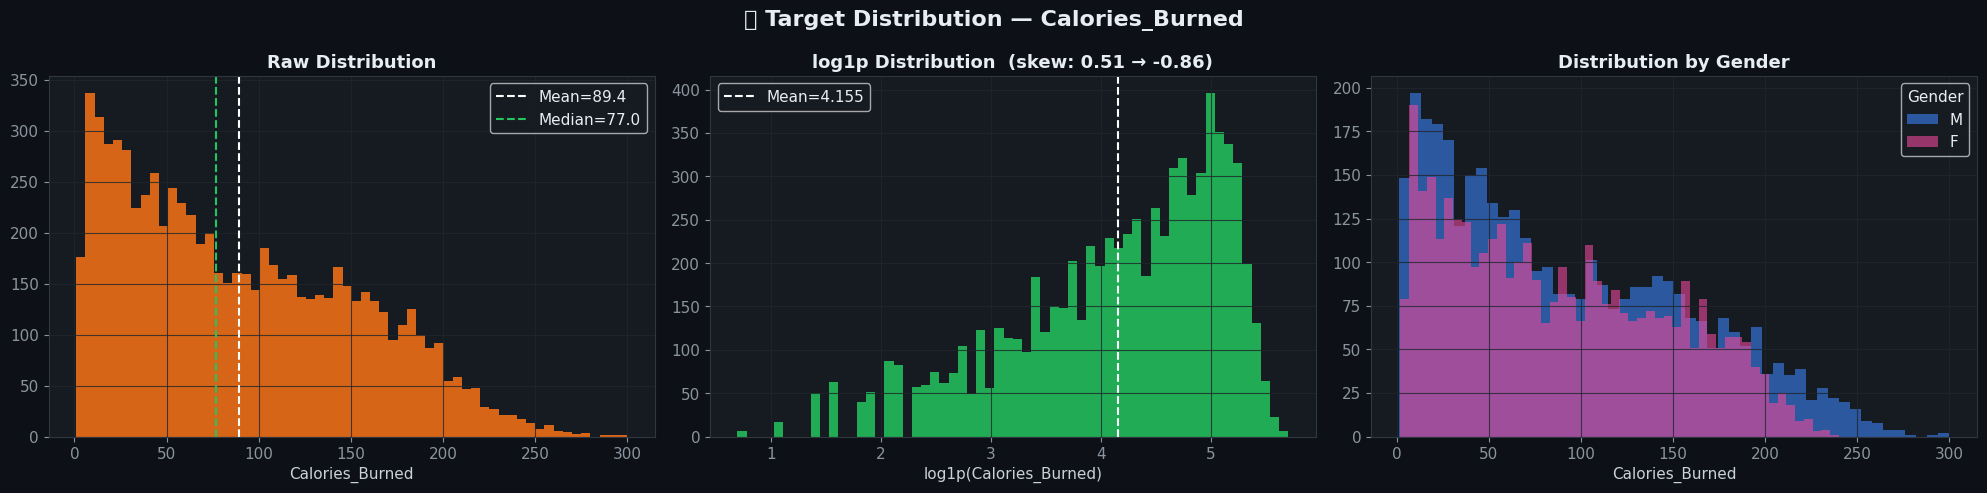

  Skewness  원본: 0.5145  →  log1p: -0.8586
  Kurtosis  원본: -0.7259  →  log1p: 0.0952


In [ ]:
# ─── 타겟 분포 (3패널)
# 타겟이 비선형구조
# -> 접근법 : 트리 기반 앙상블(XBG,LGB,CAT)
# 커널 기반(SVM)
# 딥러닝
# 다항 회귀 및 스플라인(Feature에 곱, 제곱 등을 추가하여 곡선을 만든다.) -> 모델의 해석력이 중요하다면 아주 좋은 선택지
# 비선형적인 타겟 분포를 정규 분포에 가깝게 만들어 모델의 학습 효율을 높이는게 포인트

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('📊 Target Distribution — Calories_Burned')

cal = train_raw['Calories_Burned']

# 원본
axes[0].hist(cal, bins=60, color='#f97316', alpha=0.85, edgecolor='none')
axes[0].axvline(cal.mean(), color='white', ls='--', lw=1.5, label=f'Mean={cal.mean():.1f}')
axes[0].axvline(cal.median(), color='#22c55e', ls='--', lw=1.5, label=f'Median={cal.median():.1f}')
axes[0].set_title('Raw Distribution')
axes[0].set_xlabel('Calories_Burned')
axes[0].legend()

# log1p 변환
log_cal = np.log1p(cal)
axes[1].hist(log_cal, bins=60, color='#22c55e', alpha=0.85, edgecolor='none')
axes[1].axvline(log_cal.mean(), color='white', ls='--', lw=1.5, label=f'Mean={log_cal.mean():.3f}')
axes[1].set_title(f'log1p Distribution  (skew: {cal.skew():.2f} → {log_cal.skew():.2f})')
axes[1].set_xlabel('log1p(Calories_Burned)')
axes[1].legend()

# 성별 비교
for g, c in zip(['M', 'F'], ['#3b82f6', '#ec4899']):
    axes[2].hist(train_raw[train_raw['Gender']==g]['Calories_Burned'],
                 bins=50, alpha=0.6, color=c, label=g, edgecolor='none')
axes[2].set_title('Distribution by Gender')
axes[2].set_xlabel('Calories_Burned')
axes[2].legend(title='Gender')

plt.tight_layout()
plt.savefig('plot_01_target_dist.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'  Skewness  원본: {cal.skew():.4f}  →  log1p: {log_cal.skew():.4f}')
print(f'  Kurtosis  원본: {cal.kurt():.4f}  →  log1p: {log_cal.kurt():.4f}')

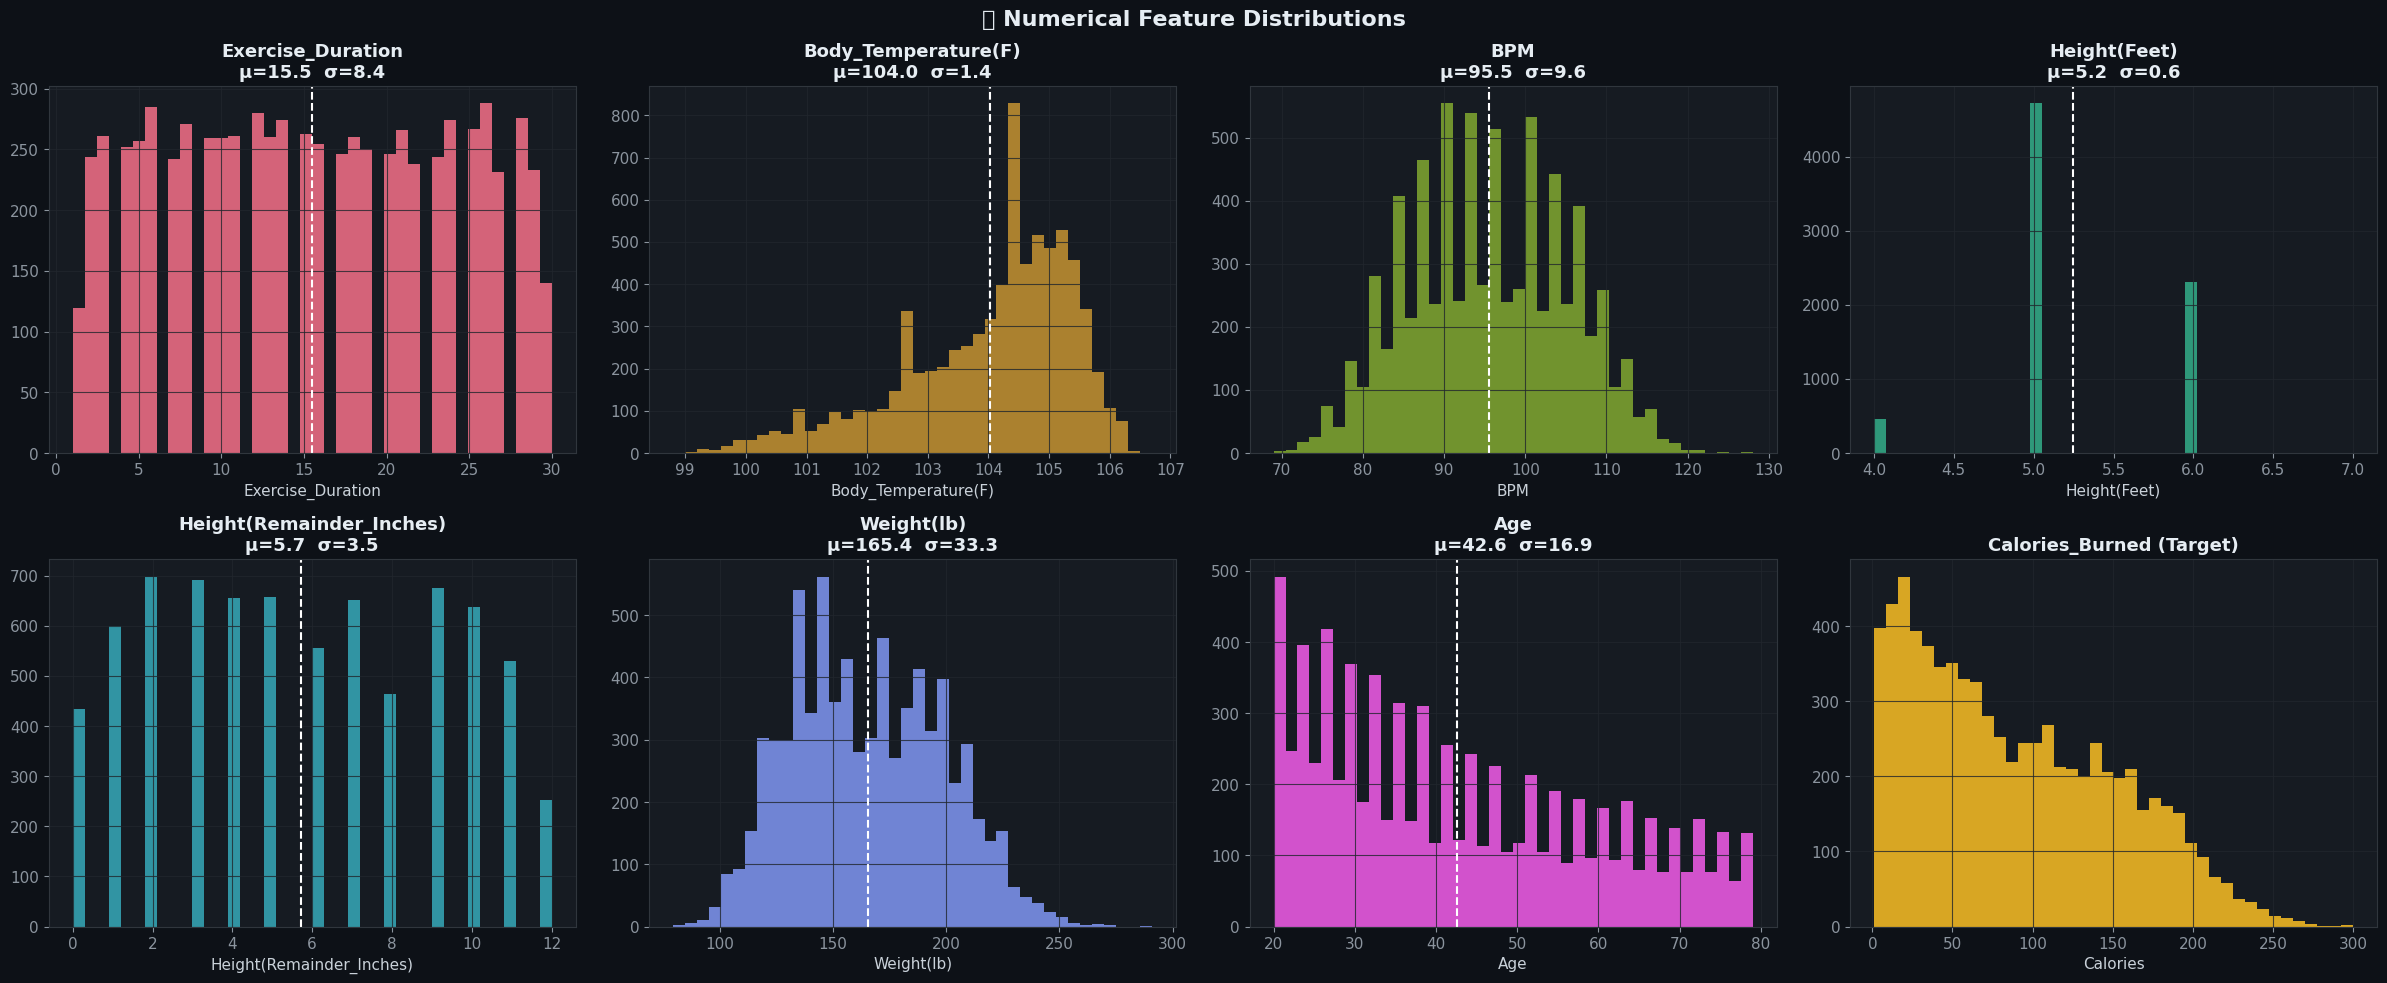

In [ ]:
# ─── 수치형 피처 분포
num_cols = ['Exercise_Duration','Body_Temperature(F)','BPM',
            'Height(Feet)','Height(Remainder_Inches)','Weight(lb)','Age']

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('📊 Numerical Feature Distributions')
axes = axes.flatten()
palette = sns.color_palette('husl', len(num_cols))

for i, col in enumerate(num_cols):
    axes[i].hist(train_raw[col], bins=40, color=palette[i], alpha=0.85, edgecolor='none')
    mu, sd = train_raw[col].mean(), train_raw[col].std()
    axes[i].axvline(mu, color='white', ls='--', lw=1.5)
    axes[i].set_title(f'{col}\nμ={mu:.1f}  σ={sd:.1f}')
    axes[i].set_xlabel(col)

axes[7].hist(train_raw['Calories_Burned'], bins=40, color='#fbbf24', alpha=0.85, edgecolor='none')
axes[7].set_title('Calories_Burned (Target)')
axes[7].set_xlabel('Calories')

plt.tight_layout()
plt.savefig('plot_02_num_distributions.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

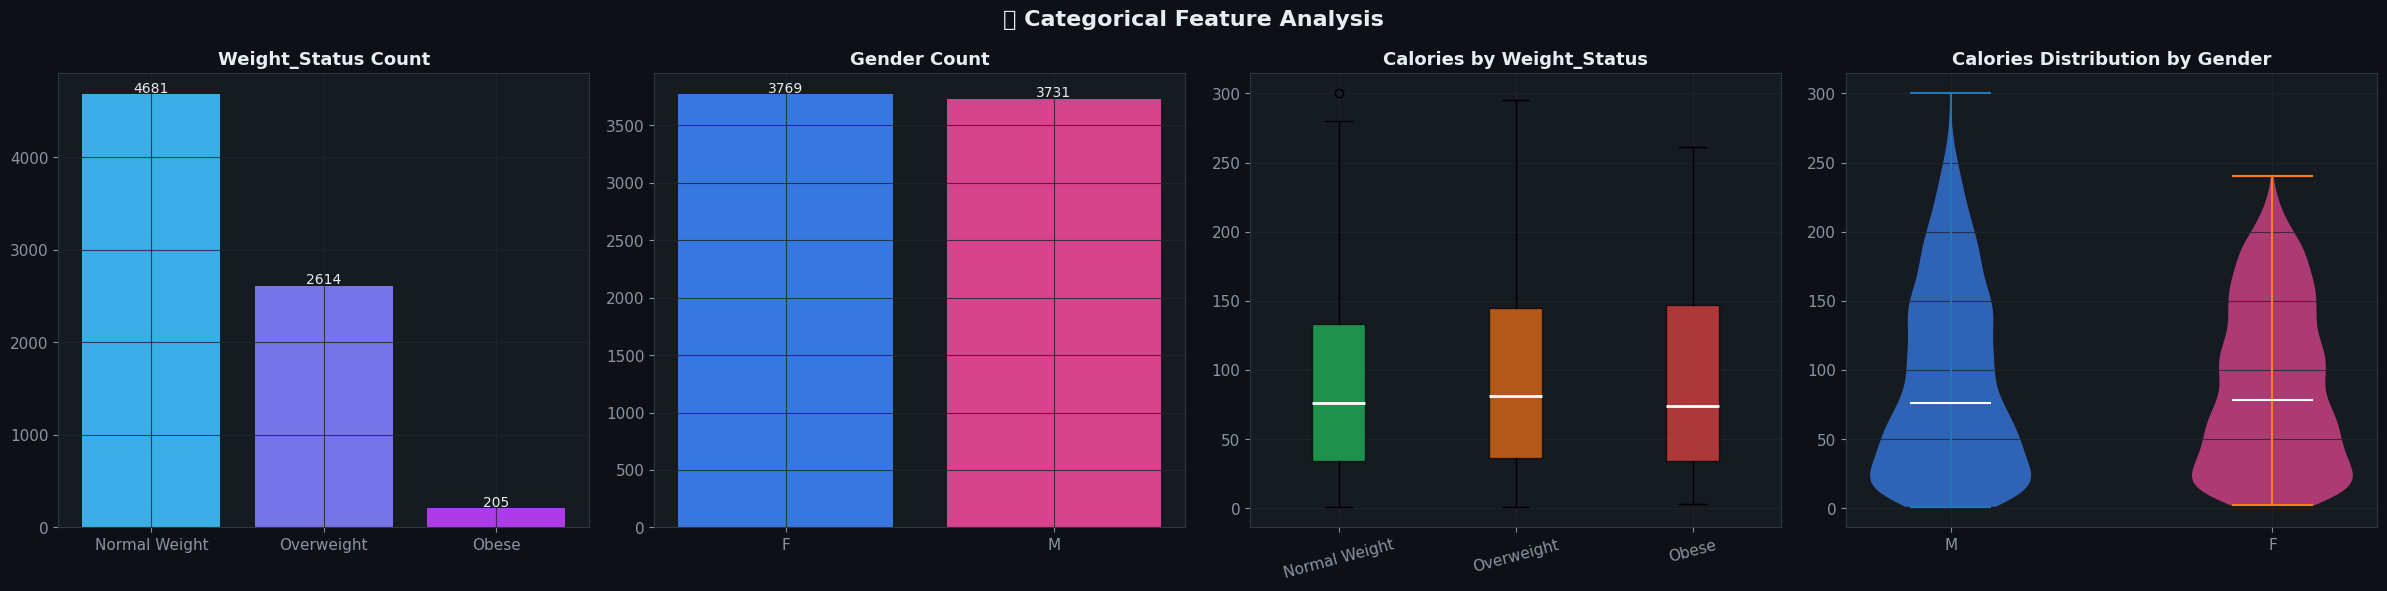

In [ ]:
# ─── 범주형 분석
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('📊 Categorical Feature Analysis')

# Weight Status 분포
ws = train_raw['Weight_Status'].value_counts()
axes[0].bar(ws.index, ws.values,
            color=sns.color_palette('cool', len(ws)), edgecolor='none', alpha=0.9)
for i,(k,v) in enumerate(ws.items()):
    axes[0].text(i, v+20, str(v), ha='center', fontsize=10)
axes[0].set_title('Weight_Status Count')

# Gender 분포
g = train_raw['Gender'].value_counts()
axes[1].bar(g.index, g.values, color=['#3b82f6','#ec4899'], edgecolor='none', alpha=0.9)
for i,(k,v) in enumerate(g.items()):
    axes[1].text(i, v+20, str(v), ha='center', fontsize=10)
axes[1].set_title('Gender Count')

# Weight Status별 Calories 박스플롯
order = ['Normal Weight','Overweight','Obese']
data_ws = [train_raw[train_raw['Weight_Status']==s]['Calories_Burned'].values for s in order]
bp = axes[2].boxplot(data_ws, labels=order, patch_artist=True,
                     medianprops={'color':'white','lw':2})
for patch, c in zip(bp['boxes'], ['#22c55e','#f97316','#ef4444']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[2].set_title('Calories by Weight_Status')
axes[2].set_xticklabels(order, rotation=15)

# Gender별 Calories 바이올린
for i, (g_val, c) in enumerate(zip(['M','F'], ['#3b82f6','#ec4899'])):
    data = train_raw[train_raw['Gender']==g_val]['Calories_Burned']
    vp = axes[3].violinplot(data, positions=[i], showmedians=True)
    for pc in vp['bodies']:
        pc.set_facecolor(c); pc.set_alpha(0.7)
    vp['cmedians'].set_color('white')
axes[3].set_xticks([0,1]); axes[3].set_xticklabels(['M','F'])
axes[3].set_title('Calories Distribution by Gender')

plt.tight_layout()
plt.savefig('plot_03_categorical.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

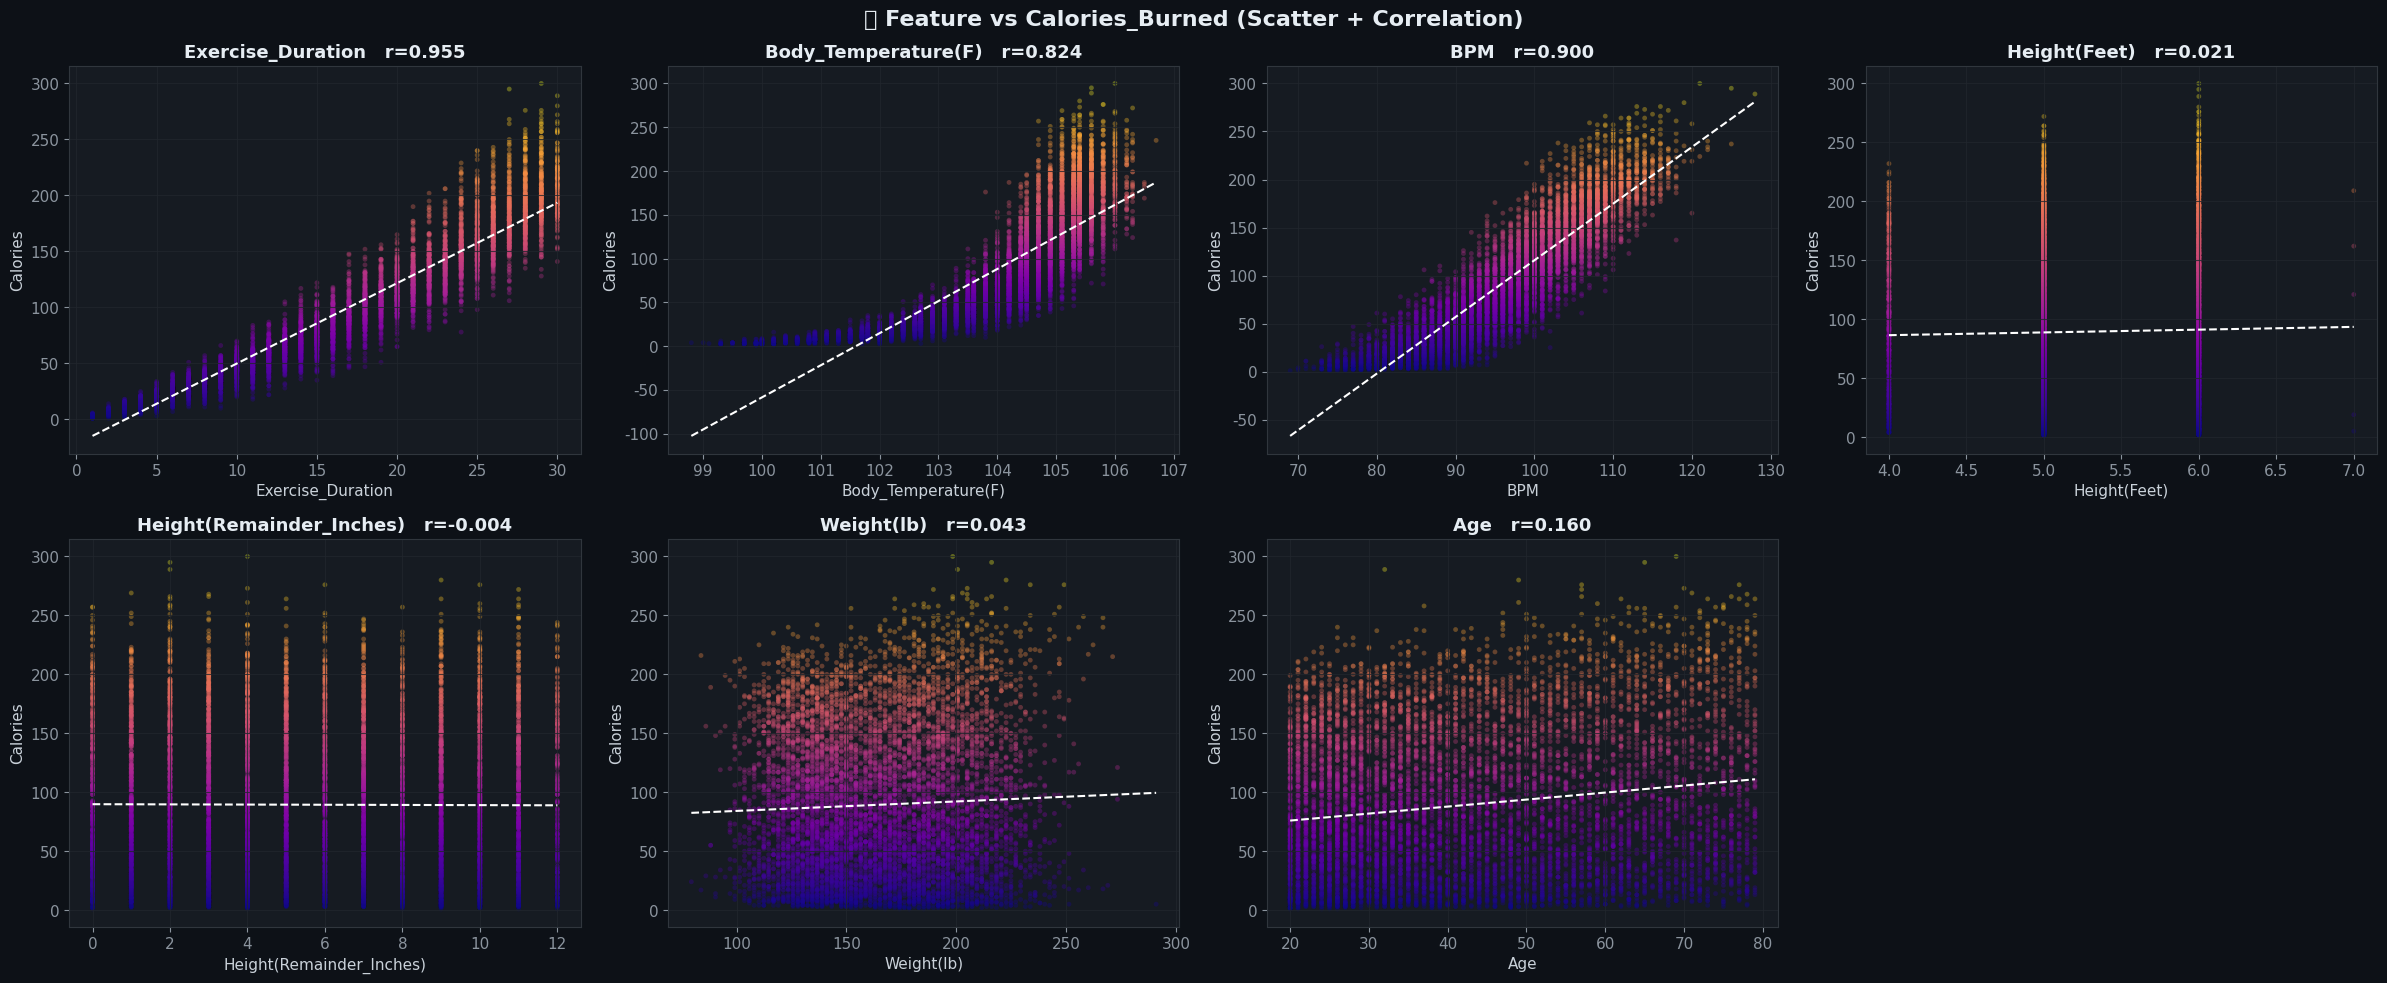

In [ ]:
# ─── 피처 vs 타겟 산점도
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('📊 Feature vs Calories_Burned (Scatter + Correlation)')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sc = axes[i].scatter(
        train_raw[col], train_raw['Calories_Burned'],
        c=train_raw['Calories_Burned'], cmap='plasma',
        alpha=0.35, s=12, edgecolors='none'
    )
    r, p = stats.pearsonr(train_raw[col], train_raw['Calories_Burned'])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Calories')
    axes[i].set_title(f'{col}   r={r:.3f}')
    # 추세선
    z = np.polyfit(train_raw[col], train_raw['Calories_Burned'], 1)
    p_ = np.poly1d(z)
    xs = np.linspace(train_raw[col].min(), train_raw[col].max(), 100)
    axes[i].plot(xs, p_(xs), 'w--', lw=1.5)

axes[7].set_visible(False)

plt.tight_layout()
plt.savefig('plot_04_scatter.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

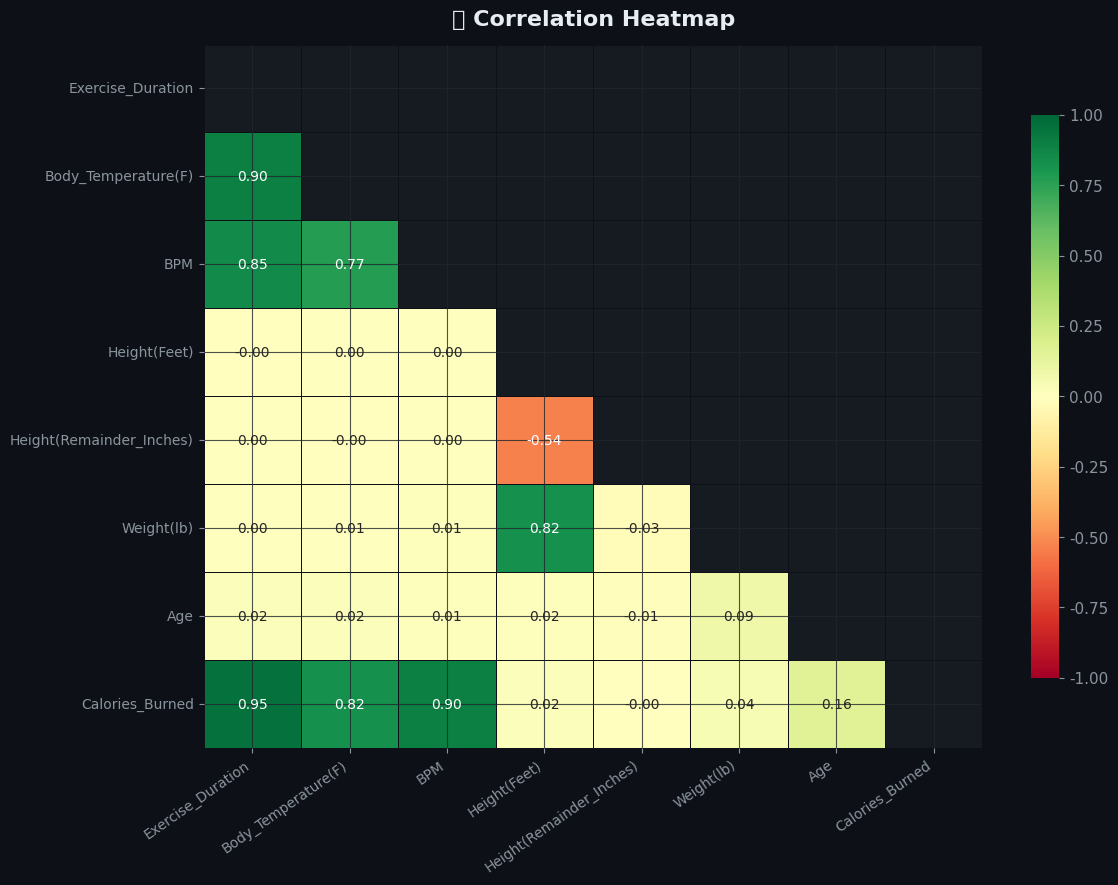


타겟과의 상관계수 순위:
Exercise_Duration           0.954783
BPM                         0.899900
Body_Temperature(F)         0.824379
Age                         0.159624
Weight(lb)                  0.042568
Height(Feet)                0.020780
Height(Remainder_Inches)    0.004381


In [ ]:
# ─── 상관관계 히트맵
fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle('📊 Correlation Heatmap')

corr = train_raw[num_cols + ['Calories_Burned']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    annot=True, fmt='.2f', annot_kws={'size':10},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#0d1117',
    cbar_kws={'shrink':0.8}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('plot_05_heatmap.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# 상관관계 순위 출력
print('\n타겟과의 상관계수 순위:')
print(corr['Calories_Burned'].drop('Calories_Burned').abs().sort_values(ascending=False).to_string())

## 🔧 4. 전처리 & 피처 엔지니어링

In [ ]:
def build_features(df):
    d = df.copy()

    # ── 단위 변환
    d['Height_in'] = d['Height(Feet)'] * 12 + d['Height(Remainder_Inches)']
    d['Height_cm'] = d['Height_in'] * 2.54
    d['Weight_kg'] = d['Weight(lb)'] * 0.453592
    d['Temp_C']    = (d['Body_Temperature(F)'] - 32) * 5 / 9

    # ── BMI & 파생
    d['BMI']              = d['Weight_kg'] / (d['Height_cm'] / 100) ** 2            # BMI는 파생변수로만 사용, 기존 변수 Weight Status를 범주형으로 변환해서 사용
    d["Thermal_Load"]     = (d["Temp_C"] - 37) * d["Exercise_Duration"]             # 열 부하
    d['Metabolic_Stress'] = d['BPM'] * d['Exercise_Duration']                       # 운동강도 근사값 # 대사 스트레스
    d['Duration_sq']      = d['Exercise_Duration'] ** 2
    d['Age_sq']           = d['Age'] ** 2
    d['BPM_Age']          = d['BPM'] / (d['Age'] + 1)
    d['Weight_Duration']  = d['Weight_kg'] * d['Exercise_Duration']
    d['Temp_BPM']         = d['Temp_C'] * d['BPM']

    # 체중 보정 운동 부하
    d["Relative_Workload"] = (d["BPM"] * d["Weight_kg"] * d["Exercise_Duration"]) / d["Age"]

    # 기초대사량 (Harris-Benedict)
    is_male = d["Gender"].astype(str).str.upper().isin(["M", "MALE"])
    d["BMR"] = np.where(
        is_male,
        66.47  + 13.75 * d["Weight_kg"] + 5.0  * d["Height_cm"] - 6.76 * d["Age"],
        655.1  + 9.56  * d["Weight_kg"] + 1.85 * d["Height_cm"] - 4.68 * d["Age"],
    )

    # ── 교차항 (핵심 피처 6가지 조합)
    key = ['Exercise_Duration','Temp_C','BPM','Age','Weight_kg','Height_cm']
    from itertools import combinations
    for f1, f2 in combinations(key, 2):
        d[f'{f1}_x_{f2}'] = d[f1] * d[f2]

    # ── 범주형 인코딩                                                               ###### 범주형 인코딩 최소화 해야함( 타겟이 비선형 )
    d['Gender_enc']      = (d['Gender'] == 'M').astype(np.int8)
    ws_map = {'Normal Weight': 0, 'Overweight': 1, 'Obese': 2}
    d['WeightStatus_enc'] = d['Weight_Status'].map(ws_map).fillna(1).astype(np.int8)

    # ── 불필요 컬럼 제거
    drop = ['ID','Height(Feet)','Height(Remainder_Inches)',
            'Weight(lb)','Gender','Weight_Status', 'Body_Temperature(F)']               #####성별은 인코딩 변수로 사용, 온도는 섭씨로 바꿔서 삭제
    if 'Calories_Burned' in d.columns:
        drop.append('Calories_Burned')
    d.drop(columns=[c for c in drop if c in d.columns], inplace=True)

    # ── 예비 파생변수(이거 넣으면 파생변수 엄청 많아져서 속도 느려짐 그냥 참고용)   ---------------- 위에 교차항 파생변수 있어서 굳이 안넣어도 될듯

    # Intensity index
    # d['Intensity_Index'] = d['BPM'] / d['Exercise_Duration']

    #  # Core interactions
    # d['HR_Temp_Interaction'] = d['BPM'] * d['Temp_c'] (위에 존재함)
    # d['HR_Duration_Interaction'] = d['BPM'] * d['Exercise_Duration'] (위에 존재함)

    # d['Metabolic_Load'] = d['BPM'] * d['Temp_c'] * d['Exercise_Duration']

    # d['Age_Duration'] = d['Age'] * d['Exercise_Duration']
    # d['Age_Body_Temp'] = d['Age'] * d['Temp_c']
    # d['Age_Duration_Temp'] = d['Age'] * d['Exercise_Duration'] * d['Temp_c']

    # d['Duration_Body_Temp'] = d['Exercise_Duration'] * d['Temp_c']

    # # Height & Weight interactions
    # d['Height_Weight'] = d['Height_cm'] * d['Weight_kg']
    # d['Height_Duration'] = d['Height_cm'] * d['Exercise_Duration']
    # d['Weight_Duration'] = d['Weight_kg'] * d['Exercise_Duration']
    # d['Weight_HeartRate'] = d['Weight_kg'] * d['BPM']
    # d['Weight_BodyTemp'] = d['Weight_kg'] * d['Temp_c']
    # d['Height_Temp_Interaction'] = d['Height_cm'] * d['Temp_c']
    # d['Weight_Duration_Temp'] = d['Weight_kg'] * d['Exercise_Duration'] * d['Temp_c']
    # d['Height_Duration_Temp'] = d['Height_cm'] * d['Exercise_Duration'] * d['Temp_c']
    # d['Weight_HR_Duration'] = d['Weight_kg'] * d['BPM'] * d['Exercise_Duration']
    # d['Height_HR_Duration'] = d['Height_cm'] * d['BPM'] * d['Exercise_Duration']

    # # Advanced exertion interactions
    # d['Weight_Intensity_Index'] = d['Weight_kg'] * d['Intensity_Index']
    # d['Height_Intensity_Index'] = d['Height_cm'] * d['Intensity_Index']
    # d['Weight_HR_Temp_Interaction'] = d['Weight_kg'] * d['HR_Temp_Interaction']
    # d['Height_HR_Temp_Interaction'] = d['Height_cm'] * d['HR_Temp_Interaction']

    # # Ratio and Normalized Features
    # d['HR_per_kg'] = d['BPM'] / d['Weight_kg']
    # d['Duration_per_kg'] = d['Exercise_Duration'] / d['Weight_kg']
    # d['Temp_per_kg'] = d['Temp_c'] / d['Weight_kg']
    # d['HR_per_cm'] = d['BPM'] / d['Height_cm']
    # d['Duration_per_cm'] = d['Exercise_Duration'] / d['Height_cm']
    # # Using height_m for BMI consistency (if a new BMI column is desired, otherwise 'bmi' is already present)
    # d['BMI_recalc'] = d['Weight_kg'] / (d['height_m']) ** 2 # Renamed to avoid confusion with existing 'bmi'

    # # Energy & exertion approximations
    # d['Energy_Exerted'] = d['Weight_kg'] * d['BPM'] * d['Exercise_Duration'] / 10000
    # d['Weighted_Intensity'] = d['Intensity_Index'] * d['Weight_kg']

    # # BMR interactions
    # d['BMR'] = d['BMR'] * d['BPM']
    # d['BMR_Duration'] = d['BMR'] * d['Exercise_Duration']
    # d['BMR_Temp'] = d['BMR'] * d['Temp_c']
    # d['BMR_Intensity'] = d['BMR'] * d['Intensity_Index']

    # # Polynomial and log features
    # d['HR_Squared'] = d['BPM'] ** 2
    # d['Duration_Squared'] = d['Exercise_Duration'] ** 2
    # d['Temp_Squared'] = d['Temp_c'] ** 2
    # d['Log_HR'] = np.log1p(d['BPM'])

    # # Gender-based interaction features (using string comparison for Gender before LabelEncoding)
    # d['Gender_male_HR'] = d['BPM'] * (d['Gender'].astype(str).str.upper() == 'M')
    # d['Gender_female_HR'] = d['BPM'] * (d['Gender'].astype(str).str.upper() == 'F')

    # d['Gender_male_Weight'] = d['weight_kg'] * (d['Gender'].astype(str).str.upper() == 'M')
    # d['Gender_female_Weight'] = d['weight_kg'] * (d['Gender'].astype(str).str.upper() == 'F')

    return d


X     = build_features(train_raw)
y     = np.log1p(train_raw['Calories_Burned'].values)
X_test= build_features(test_raw)

FEATURES = X.columns.tolist()
print(f'✅ 피처 수 : {len(FEATURES)}')
print(f'   피처 목록: {FEATURES}')

✅ 피처 수 : 34
   피처 목록: ['Exercise_Duration', 'BPM', 'Age', 'Height_in', 'Height_cm', 'Weight_kg', 'Temp_C', 'BMI', 'Thermal_Load', 'Metabolic_Stress', 'Duration_sq', 'Age_sq', 'BPM_Age', 'Weight_Duration', 'Temp_BPM', 'Relative_Workload', 'BMR', 'Exercise_Duration_x_Temp_C', 'Exercise_Duration_x_BPM', 'Exercise_Duration_x_Age', 'Exercise_Duration_x_Weight_kg', 'Exercise_Duration_x_Height_cm', 'Temp_C_x_BPM', 'Temp_C_x_Age', 'Temp_C_x_Weight_kg', 'Temp_C_x_Height_cm', 'BPM_x_Age', 'BPM_x_Weight_kg', 'BPM_x_Height_cm', 'Age_x_Weight_kg', 'Age_x_Height_cm', 'Weight_kg_x_Height_cm', 'Gender_enc', 'WeightStatus_enc']


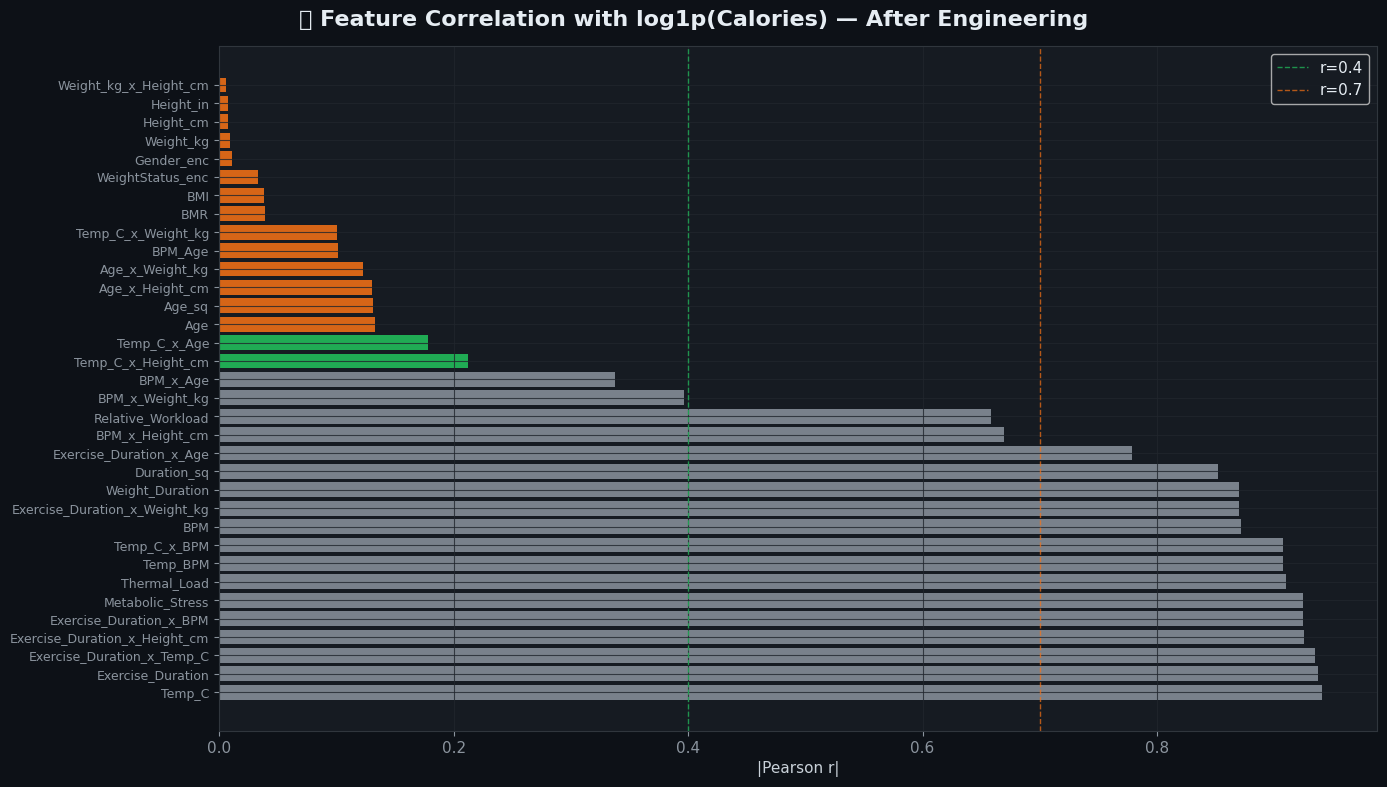


Top-10 피처:
Temp_C                           0.940601
Exercise_Duration                0.936883
Exercise_Duration_x_Temp_C       0.934806
Exercise_Duration_x_Height_cm    0.925084
Exercise_Duration_x_BPM          0.924496
Metabolic_Stress                 0.924496
Thermal_Load                     0.909780
Temp_BPM                         0.907792
Temp_C_x_BPM                     0.907792
BPM                              0.871644


In [ ]:
# ─── 엔지니어링 후 상관관계 확인
fe_corr = pd.concat([X, pd.Series(y, name='log_Calories')], axis=1).corr()['log_Calories']
fe_corr = fe_corr.drop('log_Calories').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('📊 Feature Correlation with log1p(Calories) — After Engineering')

colors = ['#f97316' if v > 0.7 else '#22c55e' if v > 0.4 else '#8b949e'
          for v in fe_corr.values]
ax.barh(range(len(fe_corr)), fe_corr.values[::-1][::-1], color=colors[::-1], alpha=0.85, edgecolor='none')
ax.set_yticks(range(len(fe_corr)))
ax.set_yticklabels(fe_corr.index, fontsize=9)
ax.set_xlabel('|Pearson r|')
ax.axvline(0.4, color='#22c55e', ls='--', lw=1, alpha=0.7, label='r=0.4')
ax.axvline(0.7, color='#f97316', ls='--', lw=1, alpha=0.7, label='r=0.7')
ax.legend()

plt.tight_layout()
plt.savefig('plot_06_feature_corr.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('\nTop-10 피처:')
print(fe_corr.head(10).to_string())

## 🔬 5. 하이퍼파라미터 최적화 — Optuna (TPE + MedianPruner)

**이전 최적 파라미터를 시작점으로 탐색 범위 집중:**
- **XGB**: `n_estimators≈1776, max_depth=5, lr≈0.019, subsample≈0.53, colsample≈0.71`
- **LGB**: `n_estimators≈1595, num_leaves=204, lr≈0.059, subsample≈0.98, min_child=15`
- **CAT**: `iterations≈1833, depth=6, lr≈0.040, l2≈0.015, bagging_temp≈0.43`

In [ ]:
X_arr  = X.values.astype('float32')
Xt_arr = X_test.values.astype('float32')
OPTUNA_KF = KFold(n_splits=OPTUNA_FOLDS, shuffle=True, random_state=SEED)


# ════════════════════════════════════════════════════
#  XGBoost — 이전 최적값(n_est=1776, depth=5, lr=0.019) 근방 집중 탐색
# ════════════════════════════════════════════════════
def objective_xgb(trial):
    param = {
        'n_estimators'     : trial.suggest_int  ('n_estimators',     1000, 3000),
        'max_depth'        : trial.suggest_int  ('max_depth',            4,    7),
        'learning_rate'    : trial.suggest_float('learning_rate',    0.008, 0.05,  log=True),
        'subsample'        : trial.suggest_float('subsample',         0.45,  0.85),
        'colsample_bytree' : trial.suggest_float('colsample_bytree',  0.55,  0.85),
        'gamma'            : trial.suggest_float('gamma',             1e-8,   1.0, log=True),
        'min_child_weight' : trial.suggest_int  ('min_child_weight',     5,   15),
        'reg_alpha'        : trial.suggest_float('reg_alpha',         1e-8,  0.1,  log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda',         0.3,  2.0),
        'max_delta_step'   : trial.suggest_int  ('max_delta_step',       0,    3),
        'tree_method'      : 'hist',
        'device'           : 'cuda' if USE_GPU else 'cpu',
        'eval_metric'      : 'rmse',
        'early_stopping_rounds': 50,
        'random_state'     : SEED,
        'verbosity'        : 0,
    }
    rmse_list = []
    for fold_i, (tr_idx, val_idx) in enumerate(OPTUNA_KF.split(X_arr, y)):
        m = XGBRegressor(**param)
        m.fit(X_arr[tr_idx], y[tr_idx],
              eval_set=[(X_arr[val_idx], y[val_idx])], verbose=False)
        rmse_list.append(np.sqrt(mean_squared_error(y[val_idx], m.predict(X_arr[val_idx]))))
        trial.report(np.mean(rmse_list), fold_i)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return np.mean(rmse_list)


# ════════════════════════════════════════════════════
#  LightGBM — 이전 최적값(n_est=1595, leaves=204, lr=0.059) 근방 집중 탐색
# ════════════════════════════════════════════════════
def objective_lgbm(trial):
    param = {
        'n_estimators'      : trial.suggest_int  ('n_estimators',     1000, 3000),
        'max_depth'         : trial.suggest_int  ('max_depth',            3,    7),
        'num_leaves'        : trial.suggest_int  ('num_leaves',          100,  300),
        'learning_rate'     : trial.suggest_float('learning_rate',    0.025,  0.12, log=True),
        'subsample'         : trial.suggest_float('subsample',         0.70,   1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree',  0.60,  0.95),
        'min_child_samples' : trial.suggest_int  ('min_child_samples',    8,   30),
        'reg_alpha'         : trial.suggest_float('reg_alpha',         1e-8,  0.05, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda',        1e-8,  0.10, log=True),
        'min_split_gain'    : trial.suggest_float('min_split_gain',    1e-8,   0.1, log=True),
        'random_state'      : SEED,
        'n_jobs'            : -1,
        'verbose'           : -1,
        'device'            : 'gpu' if USE_GPU else 'cpu',
    }
    rmse_list = []
    for fold_i, (tr_idx, val_idx) in enumerate(OPTUNA_KF.split(X_arr, y)):
        m = LGBMRegressor(**param)
        m.fit(X_arr[tr_idx], y[tr_idx],
              eval_set=[(X_arr[val_idx], y[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(-1)])
        rmse_list.append(np.sqrt(mean_squared_error(y[val_idx], m.predict(X_arr[val_idx]))))
        trial.report(np.mean(rmse_list), fold_i)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return np.mean(rmse_list)


# ════════════════════════════════════════════════════
#  CatBoost — 이전 최적값(iter=1833, depth=6, lr=0.040) 근방 집중 탐색
# ════════════════════════════════════════════════════
def objective_cat(trial):
    param = {
        'iterations'          : trial.suggest_int  ('iterations',        1000, 3000),
        'depth'               : trial.suggest_int  ('depth',                5,    8),
        'learning_rate'       : trial.suggest_float('learning_rate',    0.018, 0.08,  log=True),
        'l2_leaf_reg'         : trial.suggest_float('l2_leaf_reg',       0.005, 0.10, log=True),
        'bagging_temperature' : trial.suggest_float('bagging_temperature', 0.2,  0.7),
        'random_strength'     : trial.suggest_float('random_strength',    0.5,  2.5),
        'border_count'        : trial.suggest_int  ('border_count',       100,  200),
        'od_type'             : 'Iter',
        'od_wait'             : 50,
        'task_type'           : 'GPU' if USE_GPU else 'CPU',
        'random_seed'         : SEED,
        'verbose'             : 0,
    }
    rmse_list = []
    for fold_i, (tr_idx, val_idx) in enumerate(OPTUNA_KF.split(X_arr, y)):
        m = CatBoostRegressor(**param)
        m.fit(X_arr[tr_idx], y[tr_idx],
              eval_set=(X_arr[val_idx], y[val_idx]), verbose=False)
        rmse_list.append(np.sqrt(mean_squared_error(y[val_idx], m.predict(X_arr[val_idx]))))
        trial.report(np.mean(rmse_list), fold_i)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return np.mean(rmse_list)


# ════════════════════════════════════════════════════
#  Study 실행  (TPE Sampler + MedianPruner)
# ════════════════════════════════════════════════════
optuna_configs = {
    'XGBoost' : objective_xgb,
    'LightGBM': objective_lgbm,
    'CatBoost': objective_cat,
}

studies     = {}
best_params = {}
hp_results  = {}   # 기존 코드와 변수명 호환 유지

for name, obj_fn in optuna_configs.items():
    print(f'\n🔬 [{name}] Optuna 탐색 시작 — {N_TRIALS} trials × {OPTUNA_FOLDS} folds')
    t0 = time.time()

    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner  = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)
    study   = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
    study.optimize(obj_fn, n_trials=N_TRIALS, show_progress_bar=True)

    studies[name]     = study
    best_params[name] = study.best_params
    hp_results[name]  = study          # 기존 변수명 호환
    elapsed = time.time() - t0

    completed = len([t for t in study.trials if t.state.name == 'COMPLETE'])
    pruned    = len([t for t in study.trials if t.state.name == 'PRUNED'])
    print(f'  ✅ Best RMSE  : {study.best_value:.5f}')
    print(f'  ✂️  완료/가지치기: {completed}/{pruned}  |  ⏱ {elapsed:.1f}s ({elapsed/60:.1f}min)')
    print(f'  🏆 최적 파라미터:')
    for k, v in study.best_params.items():
        print(f'     {k:30s} = {v}')


🔍 XGBoost 하이퍼파라미터 탐색 중... (30 iterations × 5 folds)
  ✅ Best CV RMSE : 0.03366  |  시간: 447.8s
  🏆 Best params  : {'subsample': 1.0, 'reg_lambda': 3.0, 'reg_alpha': 0.05, 'n_estimators': 1000, 'min_child_weight': 2, 'max_depth': 8, 'learning_rate': 0.08, 'gamma': 0, 'colsample_bytree': 0.7}

🔍 LightGBM 하이퍼파라미터 탐색 중... (30 iterations × 5 folds)
  ✅ Best CV RMSE : 0.02813  |  시간: 1007.6s
  🏆 Best params  : {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0, 'num_leaves': 15, 'n_estimators': 800, 'min_child_samples': 5, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

🔍 CatBoost 하이퍼파라미터 탐색 중... (30 iterations × 5 folds)
  ✅ Best CV RMSE : 0.02430  |  시간: 2070.0s
  🏆 Best params  : {'subsample': 0.9, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 7, 'bagging_temperature': 0.2}

🔍 HistGB 하이퍼파라미터 탐색 중... (30 iterations × 5 folds)
  ✅ Best CV RMSE : 0.02779  |  시간: 481.0s
  🏆 Best params  : {'min_samples_leaf': 30, 'max_leaf_nodes': 63, 'max_iter': 1000

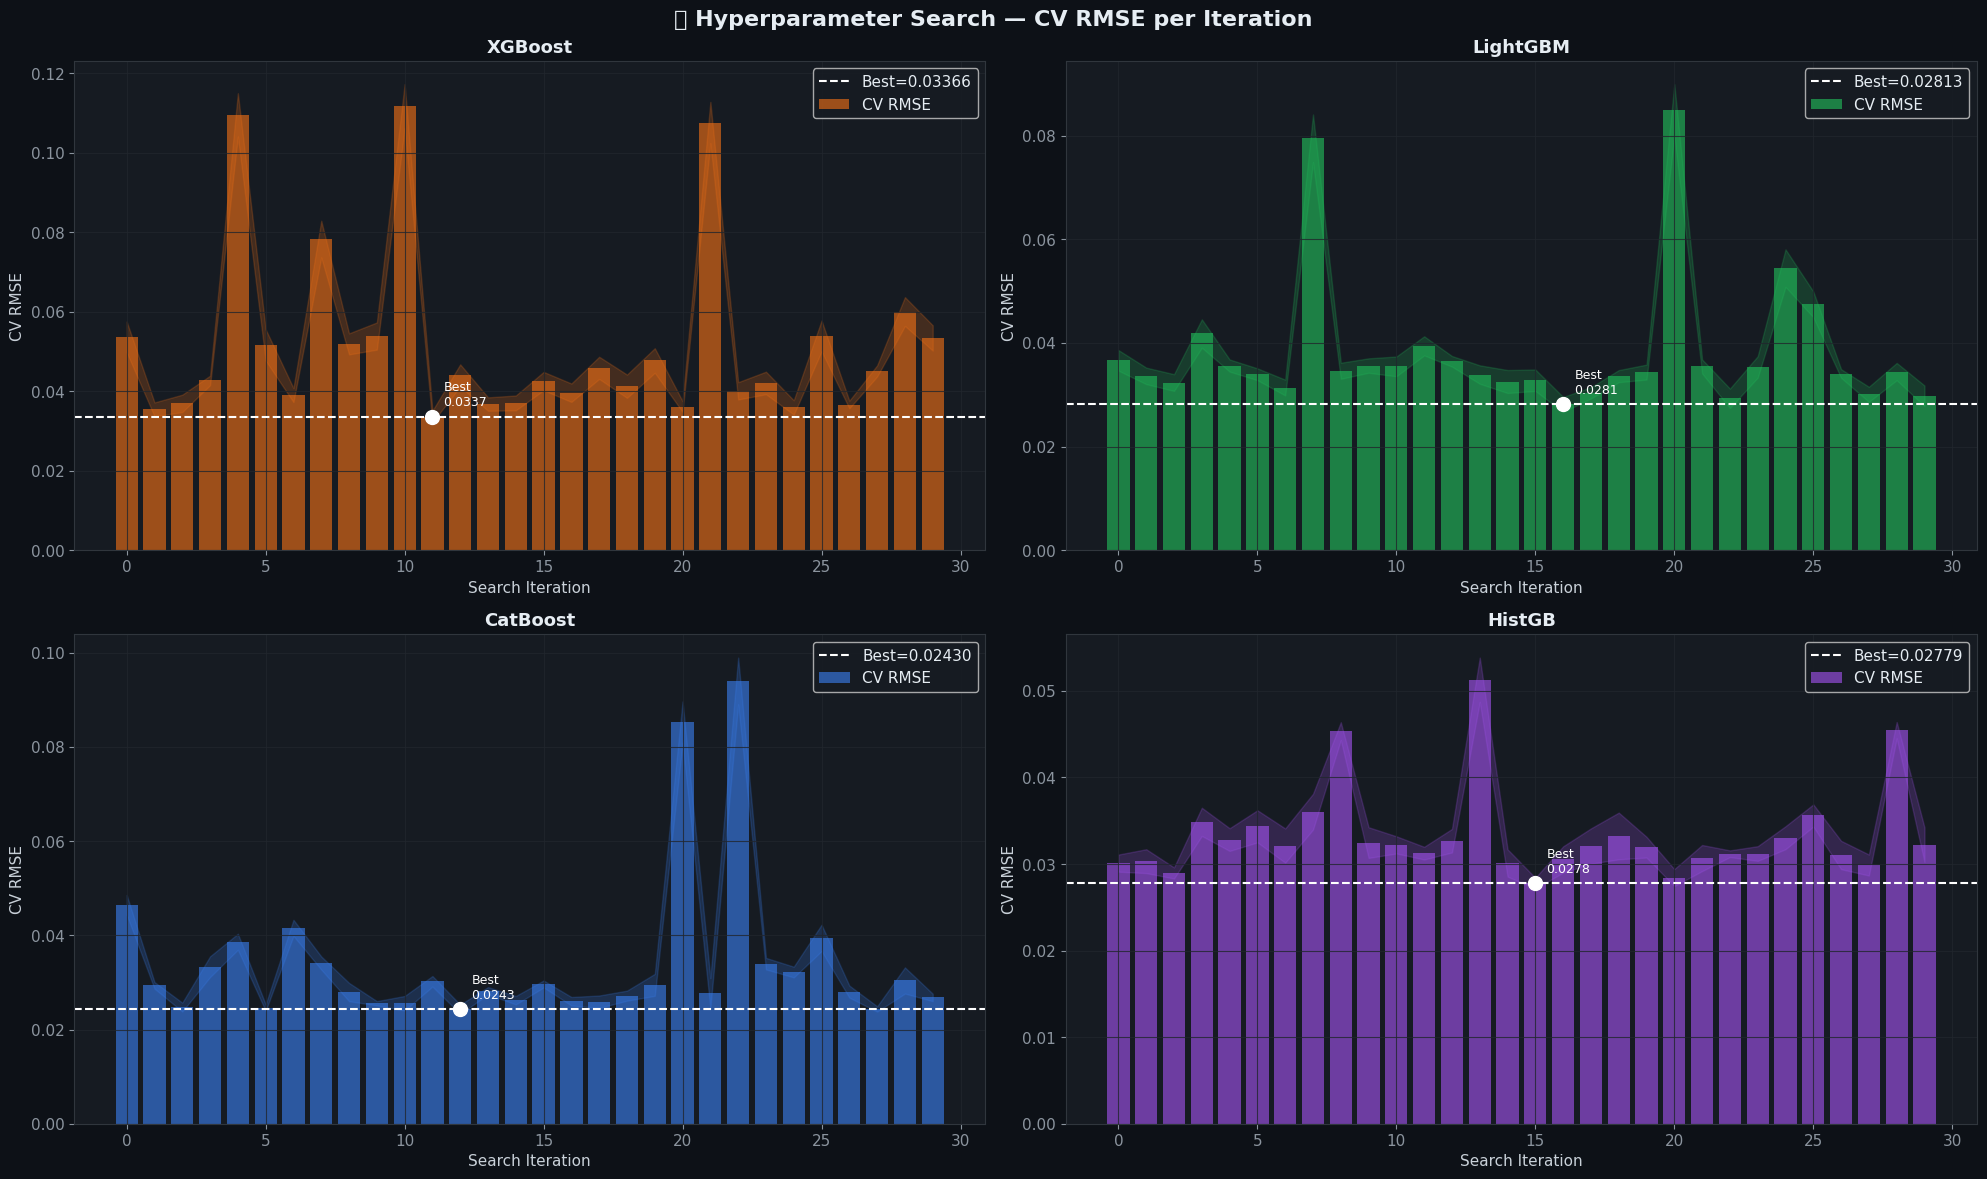

In [ ]:
# ─── Optuna 탐색 시각화 (최적화 히스토리 + 파라미터 중요도)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('🔬 Optuna Study — Optimization History & Parameter Importance')

for col, (name, study) in enumerate(studies.items()):
    c = MODEL_COLORS[name]
    trials_df = study.trials_dataframe()
    completed = trials_df[trials_df['state'] == 'COMPLETE'].copy().sort_values('number')

    # 상단: 최적화 히스토리
    ax_top = axes[0, col]
    ax_top.scatter(completed['number'], completed['value'],
                   alpha=0.5, s=25, color=c, edgecolors='none', label='Trial RMSE')
    running_min = completed['value'].cummin()
    ax_top.plot(completed['number'], running_min, color='white', lw=2, label='Best so far')
    best_v = study.best_value
    ax_top.axhline(best_v, color='gold', ls='--', lw=1.5, label=f'Best={best_v:.5f}')
    ax_top.scatter([study.best_trial.number], [best_v],
                   color='gold', s=200, zorder=6, marker='*')
    ax_top.set_title(f'{name}')
    ax_top.set_xlabel('Trial'); ax_top.set_ylabel('CV RMSE')
    ax_top.legend(fontsize=9)

    # 하단: 파라미터 중요도
    ax_bot = axes[1, col]
    try:
        imp = optuna.importance.get_param_importances(study)
        params_i = list(imp.keys())[:8]
        vals_i   = [imp[p] for p in params_i]
        bar_c = [c if v == max(vals_i) else '#8b949e' for v in vals_i]
        ax_bot.barh(params_i[::-1], vals_i[::-1], color=bar_c[::-1], alpha=0.85, edgecolor='none')
        ax_bot.set_title(f'{name} — Param Importance')
        ax_bot.set_xlabel('Importance')
    except Exception:
        ax_bot.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax_bot.transAxes)

plt.tight_layout()
plt.savefig('plot_06_optuna_history.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [ ]:
# ─── 최적 파라미터 요약 표
print('='*70)
print('  Optuna 최적 파라미터 요약')
print('='*70)
rows = []
for name, study in studies.items():
    row = {'Model': name, 'Optuna_RMSE': round(study.best_value, 6)}
    row.update(study.best_params)
    rows.append(row)
    print(f'\n  [{name}]  Optuna RMSE = {study.best_value:.5f}')
    for k, v in study.best_params.items():
        print(f'    {k:35s} = {v}')

pd.DataFrame(rows).to_csv('best_params_optuna.csv', index=False)
print('\n\n✅ best_params_optuna.csv 저장 완료')

  최적 하이퍼파라미터 및 CV RMSE 요약

  [XGBoost]  CV RMSE = 0.03366
    subsample                      = 1.0
    reg_lambda                     = 3.0
    reg_alpha                      = 0.05
    n_estimators                   = 1000
    min_child_weight               = 2
    max_depth                      = 8
    learning_rate                  = 0.08
    gamma                          = 0
    colsample_bytree               = 0.7

  [LightGBM]  CV RMSE = 0.02813
    subsample                      = 0.7
    reg_lambda                     = 1.0
    reg_alpha                      = 0
    num_leaves                     = 15
    n_estimators                   = 800
    min_child_samples              = 5
    max_depth                      = 10
    learning_rate                  = 0.05
    colsample_bytree               = 0.8

  [CatBoost]  CV RMSE = 0.02430
    subsample                      = 0.9
    learning_rate                  = 0.1
    l2_leaf_reg                    = 1
    iterations           

## 🔄 6. KFold 교차검증 학습

In [ ]:
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

# 최적 파라미터로 최종 모델 구성
def make_final_model(name):
    p = dict(best_params[name])
    if name == 'XGBoost':
        p.update({'tree_method':'hist', 'device':'cuda' if USE_GPU else 'cpu',
                  'eval_metric':'rmse', 'early_stopping_rounds':100,
                  'random_state':SEED, 'verbosity':0})
        return XGBRegressor(**p)
    elif name == 'LightGBM':
        p.update({'random_state':SEED, 'n_jobs':-1, 'verbose':-1,
                  'device':'gpu' if USE_GPU else 'cpu'})
        return LGBMRegressor(**p)
    else:  # CatBoost
        p.update({'task_type':'GPU' if USE_GPU else 'CPU', 'random_seed':SEED,
                  'verbose':0, 'od_type':'Iter', 'od_wait':100})
        return CatBoostRegressor(**p)

model_names = ['XGBoost', 'LightGBM', 'CatBoost']

oof_dict       = {}
pred_dict      = {}
fold_rmse_dict = {}
best_models    = {}   # Feature Importance용

for name in model_names:
    print(f'\n{"─"*55}')
    print(f'  🏋️  {name}  ({FOLDS}-Fold CV 학습)')
    print(f'{"─"*55}')

    oof  = np.zeros(len(y))
    pred = np.zeros(len(Xt_arr))
    fold_rmses = []
    last_model = None

    for fold_i, (tr_idx, val_idx) in enumerate(kf.split(X_arr, y)):
        Xtr, ytr   = X_arr[tr_idx], y[tr_idx]
        Xval, yval = X_arr[val_idx], y[val_idx]

        m = make_final_model(name)

        if name == 'XGBoost':
            m.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
        elif name == 'LightGBM':
            m.fit(Xtr, ytr, eval_set=[(Xval, yval)],
                  callbacks=[lgb.early_stopping(100, verbose=False),
                              lgb.log_evaluation(-1)])
        else:  # CatBoost
            m.fit(Xtr, ytr, eval_set=(Xval, yval), verbose=False)

        oof[val_idx] = m.predict(Xval)
        pred        += m.predict(Xt_arr)
        last_model   = m

        fold_rmse = np.sqrt(mean_squared_error(yval, oof[val_idx]))
        fold_rmses.append(fold_rmse)
        print(f'  Fold {fold_i+1:2d}/{FOLDS}  RMSE = {fold_rmse:.5f}')

    pred /= FOLDS
    oof_rmse = np.sqrt(mean_squared_error(y, oof))

    oof_dict[name]       = oof
    pred_dict[name]      = pred
    fold_rmse_dict[name] = fold_rmses
    best_models[name]    = last_model

    print(f'\n  ⭐ OOF RMSE   = {oof_rmse:.5f}')
    print(f'     Fold Mean  = {np.mean(fold_rmses):.5f} ± {np.std(fold_rmses):.5f}')


───────────────────────────────────────────────────────
  🏋️  XGBoost  (10-Fold CV 학습)
───────────────────────────────────────────────────────
  Fold  1/10  RMSE = 0.03020
  Fold  2/10  RMSE = 0.03421
  Fold  3/10  RMSE = 0.03230
  Fold  4/10  RMSE = 0.03759
  Fold  5/10  RMSE = 0.02850
  Fold  6/10  RMSE = 0.03005
  Fold  7/10  RMSE = 0.02956
  Fold  8/10  RMSE = 0.03480
  Fold  9/10  RMSE = 0.03378
  Fold 10/10  RMSE = 0.03614

  ⭐ OOF RMSE   = 0.03284
     Fold Mean  = 0.03271 ± 0.00291

───────────────────────────────────────────────────────
  🏋️  LightGBM  (10-Fold CV 학습)
───────────────────────────────────────────────────────
  Fold  1/10  RMSE = 0.02590
  Fold  2/10  RMSE = 0.02837
  Fold  3/10  RMSE = 0.02605
  Fold  4/10  RMSE = 0.03308
  Fold  5/10  RMSE = 0.02378
  Fold  6/10  RMSE = 0.02614
  Fold  7/10  RMSE = 0.02370
  Fold  8/10  RMSE = 0.02533
  Fold  9/10  RMSE = 0.02880
  Fold 10/10  RMSE = 0.02569

  ⭐ OOF RMSE   = 0.02681
     Fold Mean  = 0.02668 ± 0.00264

──────

## 📊 7. 학습 결과 시각화

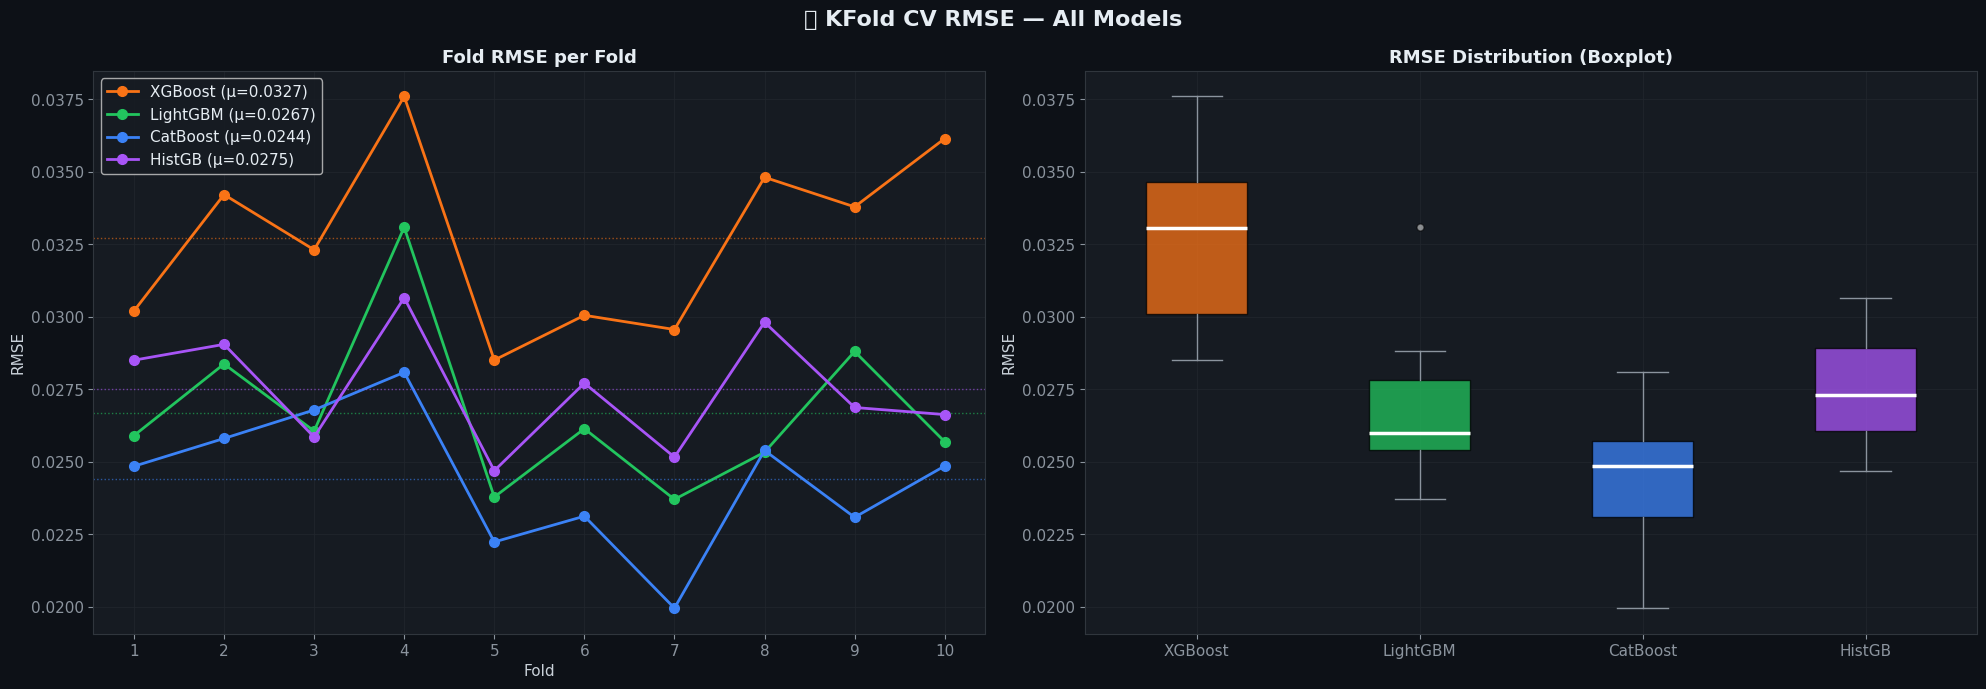

In [ ]:
# ─── Fold별 RMSE 비교 (라인 + 박스)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('📊 KFold CV RMSE — All Models')

# 라인 그래프
for name, rmses in fold_rmse_dict.items():
    x = np.arange(1, len(rmses)+1)
    axes[0].plot(x, rmses, marker='o', lw=2, ms=7,
                 color=MODEL_COLORS[name], label=f'{name} (μ={np.mean(rmses):.4f})')
    axes[0].axhline(np.mean(rmses), ls=':', lw=1, color=MODEL_COLORS[name], alpha=0.6)

axes[0].set_title('Fold RMSE per Fold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('RMSE')
axes[0].set_xticks(np.arange(1, FOLDS+1))
axes[0].legend()

# 박스 플롯
names  = list(fold_rmse_dict.keys())
data   = list(fold_rmse_dict.values())
colors = [MODEL_COLORS[n] for n in names]
bp = axes[1].boxplot(data, labels=names, patch_artist=True,
                     medianprops={'color':'white','lw':2.5})
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.75)
for w in bp['whiskers']: w.set_color('#8b949e')
for cap in bp['caps']:   cap.set_color('#8b949e')
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='white', markersize=5, alpha=0.5)

axes[1].set_title('RMSE Distribution (Boxplot)')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.savefig('plot_08_fold_rmse.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

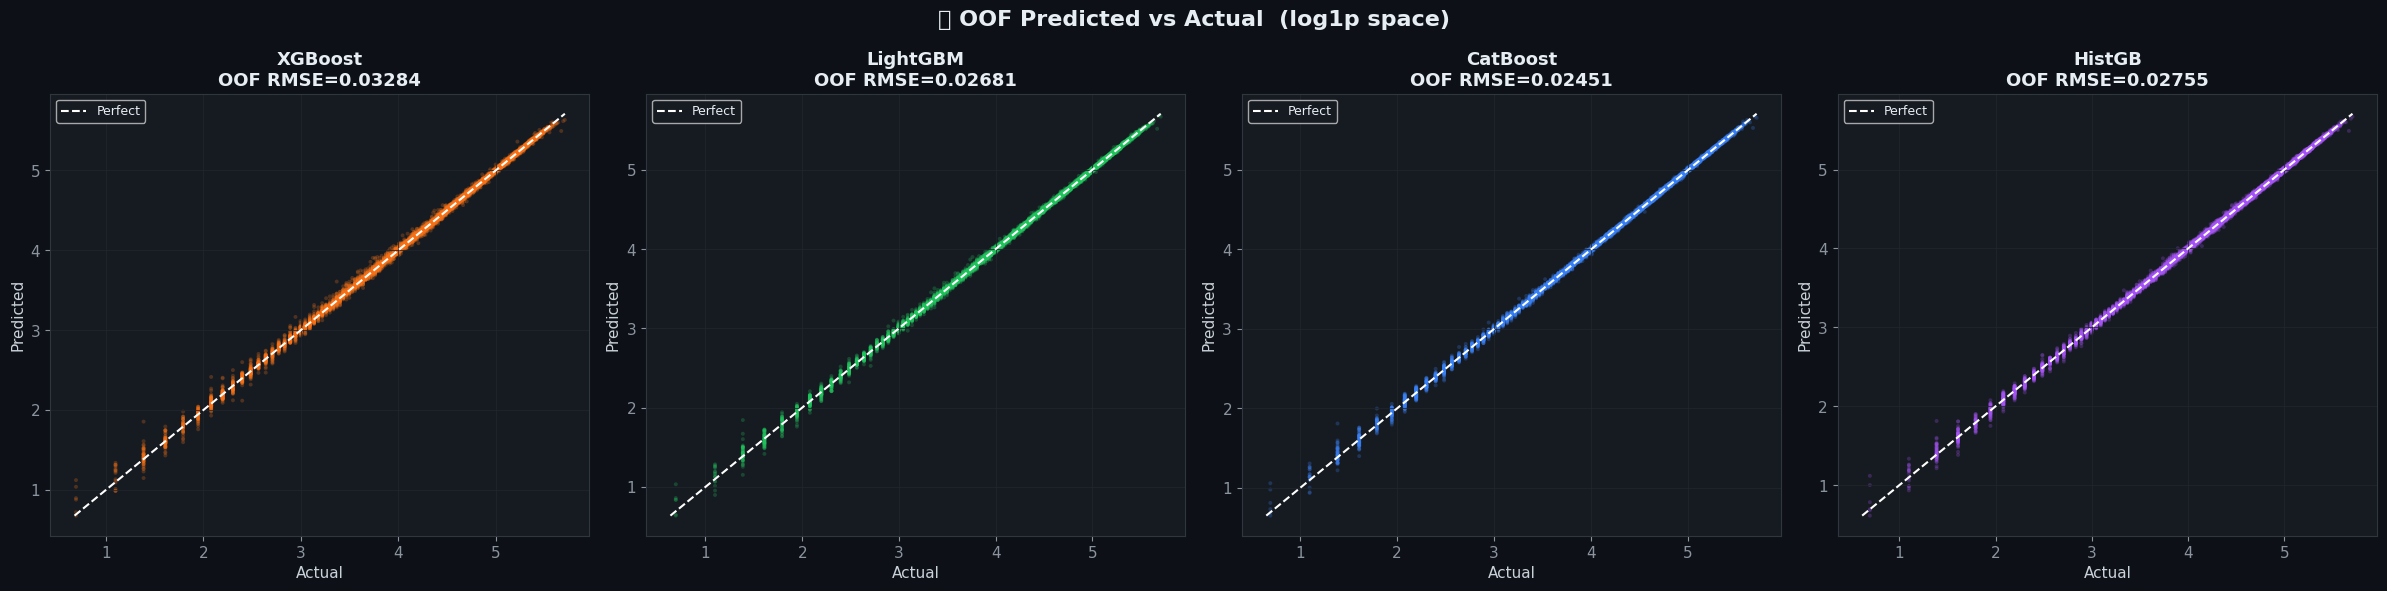

In [ ]:
# ─── OOF Predicted vs Actual
n_models = len(oof_dict)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 6))
fig.suptitle('📊 OOF Predicted vs Actual  (log1p space)')

for ax, (name, oof) in zip(axes, oof_dict.items()):
    r = np.sqrt(mean_squared_error(y, oof))
    ax.scatter(y, oof, alpha=0.25, s=8,
               c=MODEL_COLORS[name], edgecolors='none')
    lo, hi = min(y.min(), oof.min()), max(y.max(), oof.max())
    ax.plot([lo, hi], [lo, hi], 'w--', lw=1.5, label='Perfect')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nOOF RMSE={r:.5f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_09_oof_scatter.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

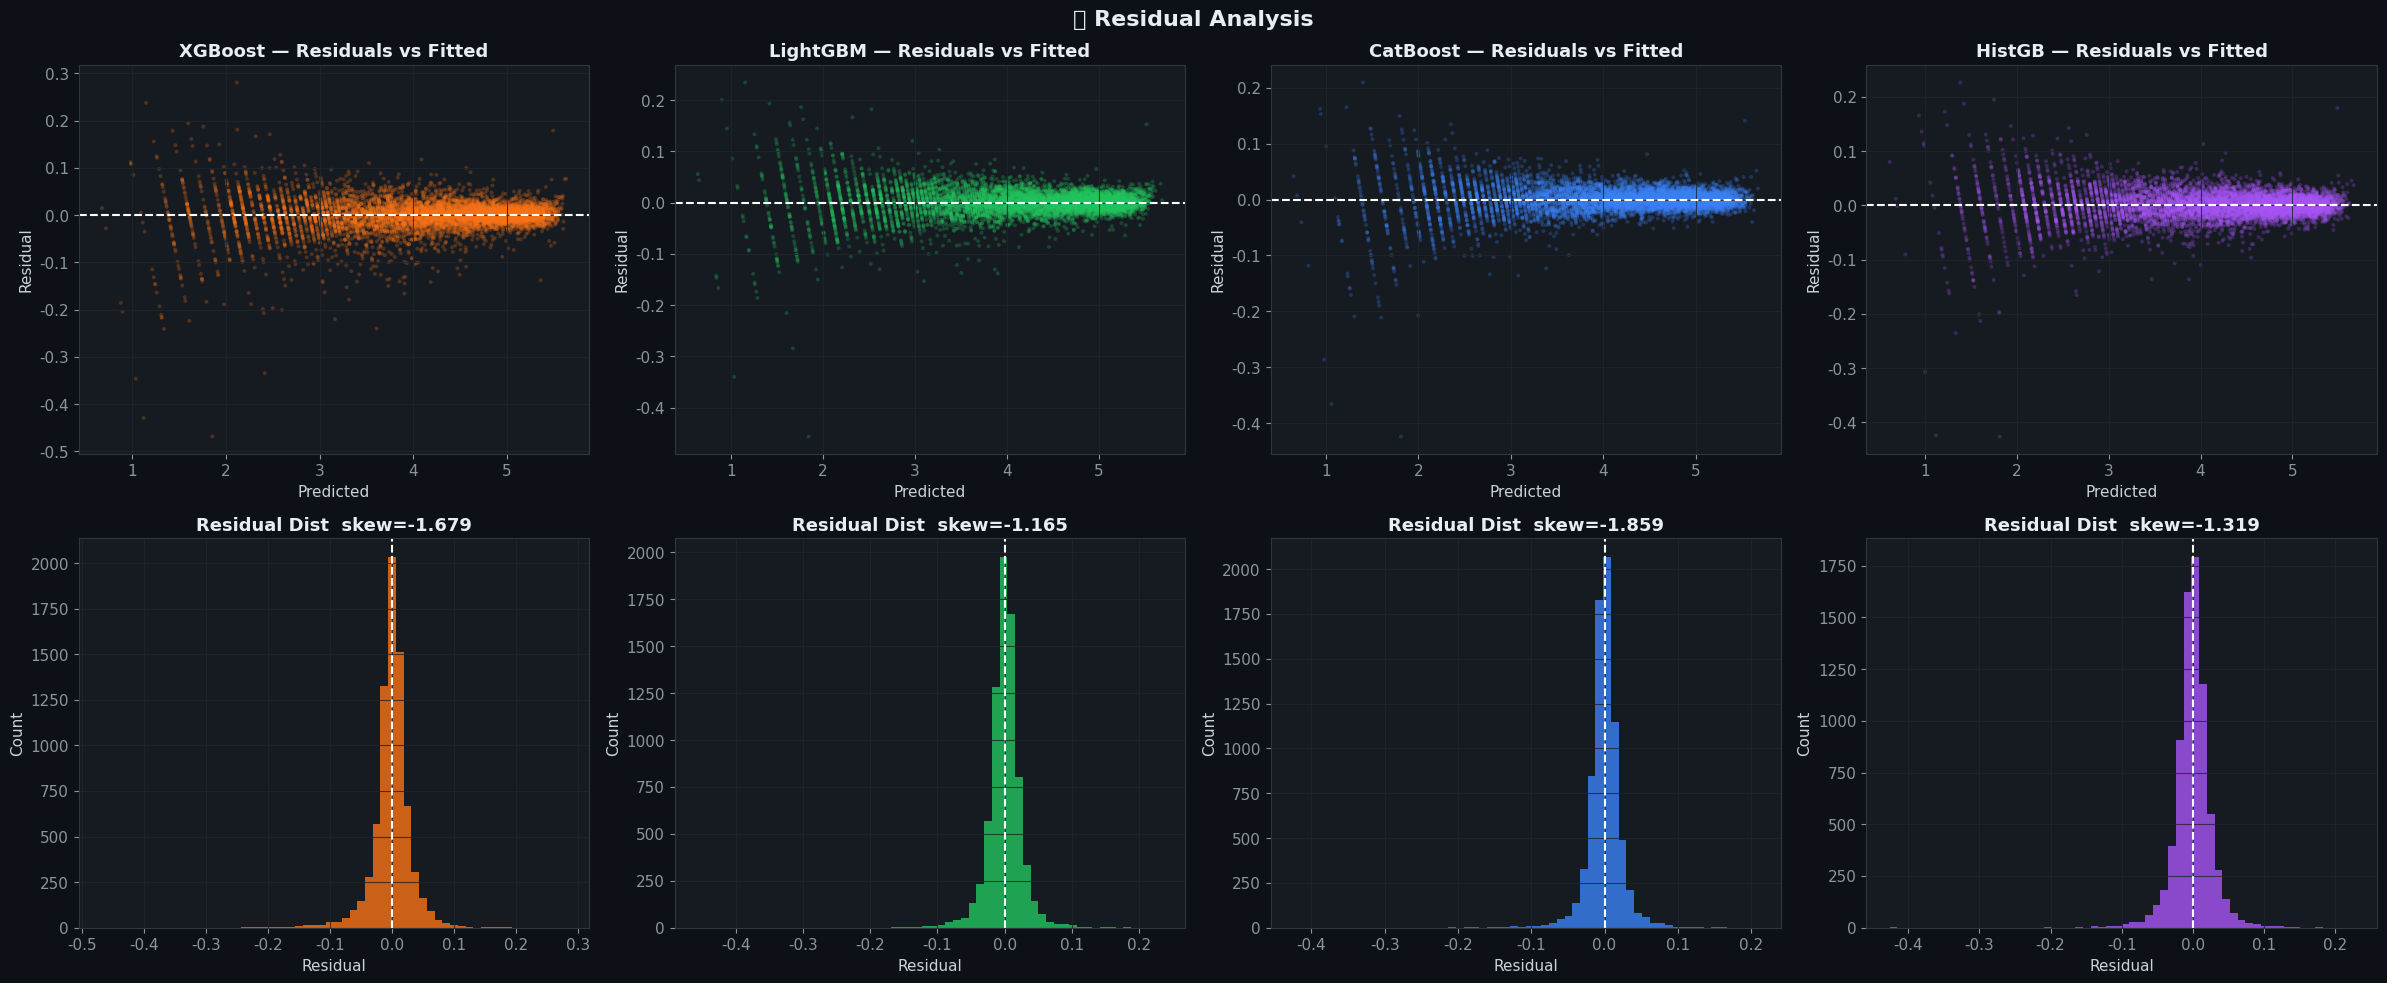

In [ ]:
# ─── 잔차(Residual) 분석
fig, axes = plt.subplots(2, n_models, figsize=(6*n_models, 10))
fig.suptitle('📊 Residual Analysis')

for col, (name, oof) in enumerate(oof_dict.items()):
    res = y - oof
    c   = MODEL_COLORS[name]

    # 잔차 vs 예측값
    axes[0, col].scatter(oof, res, alpha=0.25, s=8, color=c, edgecolors='none')
    axes[0, col].axhline(0, color='white', ls='--', lw=1.5)
    axes[0, col].set_xlabel('Predicted'); axes[0, col].set_ylabel('Residual')
    axes[0, col].set_title(f'{name} — Residuals vs Fitted')

    # 잔차 히스토그램
    axes[1, col].hist(res, bins=60, color=c, alpha=0.8, edgecolor='none')
    axes[1, col].axvline(0, color='white', ls='--', lw=1.5)
    axes[1, col].set_xlabel('Residual'); axes[1, col].set_ylabel('Count')
    axes[1, col].set_title(
        f'Residual Dist  skew={pd.Series(res).skew():.3f}'
    )

plt.tight_layout()
plt.savefig('plot_10_residuals.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

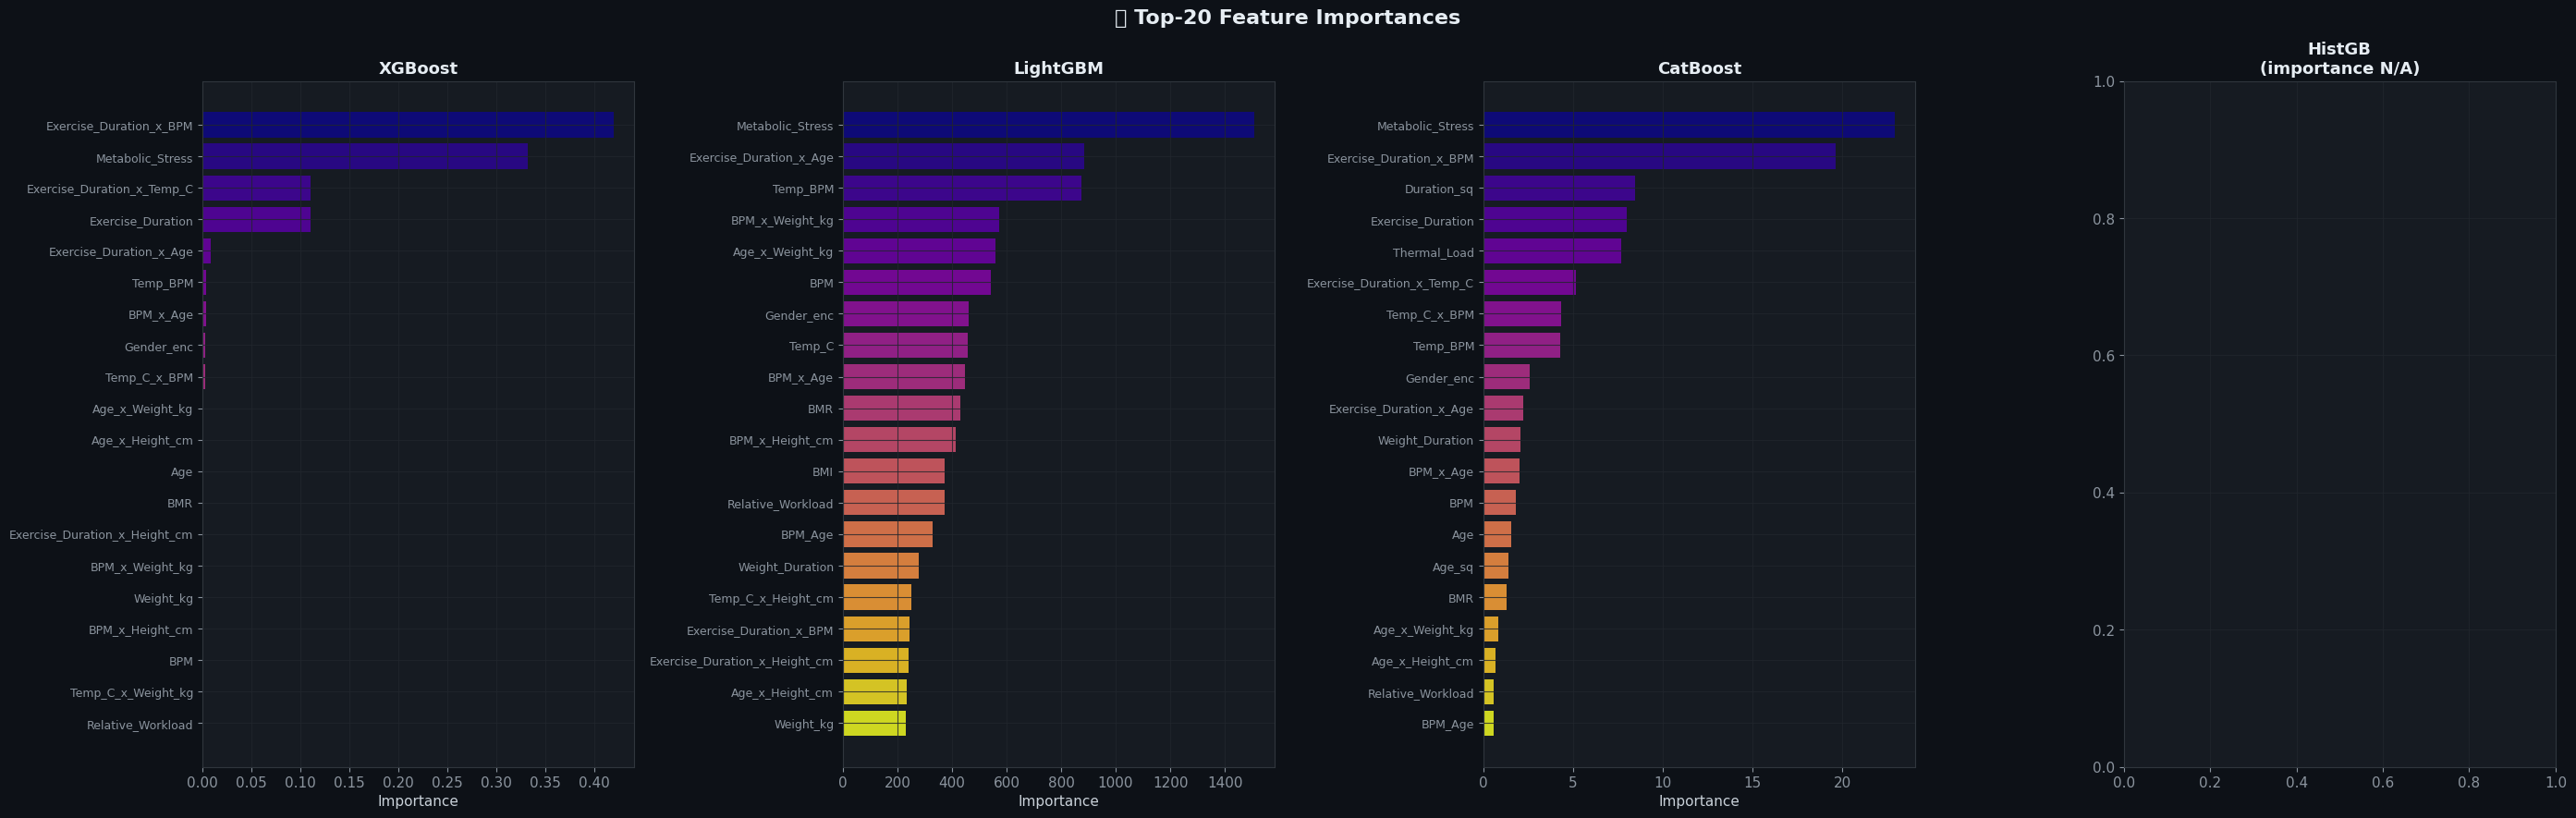

In [ ]:
# ─── Feature Importance
fig, axes = plt.subplots(1, n_models, figsize=(7*n_models, 9))
fig.suptitle('📊 Top-20 Feature Importances')
TOP = 20

for ax, (name, est) in zip(axes, best_models.items()):
    try:
        imp = est.feature_importances_
    except AttributeError:
        ax.set_title(f'{name}\n(importance N/A)'); continue

    idx = np.argsort(imp)[::-1][:TOP]
    top_f = [FEATURES[i] for i in idx]
    top_v = imp[idx]

    cmap = plt.cm.get_cmap('plasma', TOP)
    bar_colors = [cmap(i/TOP) for i in range(TOP)]

    ax.barh(range(TOP), top_v[::-1], color=bar_colors[::-1], alpha=0.85, edgecolor='none')
    ax.set_yticks(range(TOP))
    ax.set_yticklabels(top_f[::-1], fontsize=9)
    ax.set_xlabel('Importance')
    ax.set_title(f'{name}')

plt.tight_layout()
plt.savefig('plot_11_feature_importance.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 🤝 8. 앙상블 & 최종 RMSE 비교

In [ ]:
# ── 개별 모델 OOF RMSE
oof_rmses = {n: np.sqrt(mean_squared_error(y, oof_dict[n])) for n in oof_dict}

# ── Equal-weight 앙상블
eq_oof    = np.mean(list(oof_dict.values()),  axis=0)
eq_pred   = np.mean(list(pred_dict.values()), axis=0)
eq_rmse   = np.sqrt(mean_squared_error(y, eq_oof))

# ── Inverse-RMSE 가중 앙상블
inv_w   = {n: 1.0/v for n,v in oof_rmses.items()}
total_w = sum(inv_w.values())
weights = {n: v/total_w for n,v in inv_w.items()}
wtd_oof  = sum(oof_dict[n]  * weights[n] for n in weights)
wtd_pred = sum(pred_dict[n] * weights[n] for n in weights)
wtd_rmse = np.sqrt(mean_squared_error(y, wtd_oof))

# ════════════════════════════════════════════════════
#  Optuna 가중치 최적화  ← 핵심 개선 포인트
# ════════════════════════════════════════════════════
xgb_oof = oof_dict['XGBoost']
lgb_oof = oof_dict['LightGBM']
cat_oof = oof_dict['CatBoost']

def ensemble_objective(trial):
    w_xgb  = trial.suggest_float('w_xgb',  0.0, 1.0)
    w_lgbm = trial.suggest_float('w_lgbm', 0.0, 1.0)
    w_cat  = trial.suggest_float('w_cat',  0.0, 1.0)
    total  = w_xgb + w_lgbm + w_cat + 1e-9
    blend  = (w_xgb/total * xgb_oof +
              w_lgbm/total * lgb_oof +
              w_cat/total  * cat_oof)
    return np.sqrt(mean_squared_error(y, blend))

print(f'앙상블 가중치 최적화 중... ({ENSEMBLE_TRIALS} trials)')
ens_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
ens_study.optimize(ensemble_objective, n_trials=ENSEMBLE_TRIALS, show_progress_bar=True)

# 최적 가중치 적용
opt_w = ens_study.best_params
tot_w = opt_w['w_xgb'] + opt_w['w_lgbm'] + opt_w['w_cat'] + 1e-9
opt_oof  = (opt_w['w_xgb']/tot_w * xgb_oof  +
            opt_w['w_lgbm']/tot_w * lgb_oof  +
            opt_w['w_cat']/tot_w  * cat_oof)
opt_pred = (opt_w['w_xgb']/tot_w * pred_dict['XGBoost']  +
            opt_w['w_lgbm']/tot_w * pred_dict['LightGBM'] +
            opt_w['w_cat']/tot_w  * pred_dict['CatBoost'])
opt_rmse = np.sqrt(mean_squared_error(y, opt_oof))

# ── 결과 정리
all_rmses = {
    **oof_rmses,
    'EqualEnsemble'   : eq_rmse,
    'WeightedEnsemble': wtd_rmse,
    'OptEnsemble'     : opt_rmse,   # ← Optuna 가중치 앙상블
}
best_strategy = min(all_rmses, key=all_rmses.get)

print('\n' + '='*60)
print('  RMSE 종합 비교')
print('='*60)
for k, v in sorted(all_rmses.items(), key=lambda x: x[1]):
    marker = '  ← BEST ✅' if k == best_strategy else ''
    print(f'  {k:25s} : {v:.5f}{marker}')
print('='*60)

print(f'\n  Optuna 최적 가중치:')
print(f'    XGBoost  : {opt_w["w_xgb"]/tot_w:.4f}')
print(f'    LightGBM : {opt_w["w_lgbm"]/tot_w:.4f}')
print(f'    CatBoost : {opt_w["w_cat"]/tot_w:.4f}')

# ── 앙상블 OOF pred 업데이트 (submission용)
if best_strategy == 'OptEnsemble':
    final_ensemble_oof  = opt_oof
    final_ensemble_pred = opt_pred
elif best_strategy == 'EqualEnsemble':
    final_ensemble_oof  = eq_oof
    final_ensemble_pred = eq_pred
else:
    final_ensemble_oof  = wtd_oof
    final_ensemble_pred = wtd_pred

  RMSE 종합 비교
  WeightedEnsemble          : 0.02260  ← BEST ✅
  EqualEnsemble             : 0.02289
  CatBoost                  : 0.02451
  LightGBM                  : 0.02681
  HistGB                    : 0.02755
  XGBoost                   : 0.03284

앙상블 가중치:
  XGBoost: 0.2102
  LightGBM: 0.2575
  CatBoost: 0.2817
  HistGB: 0.2506


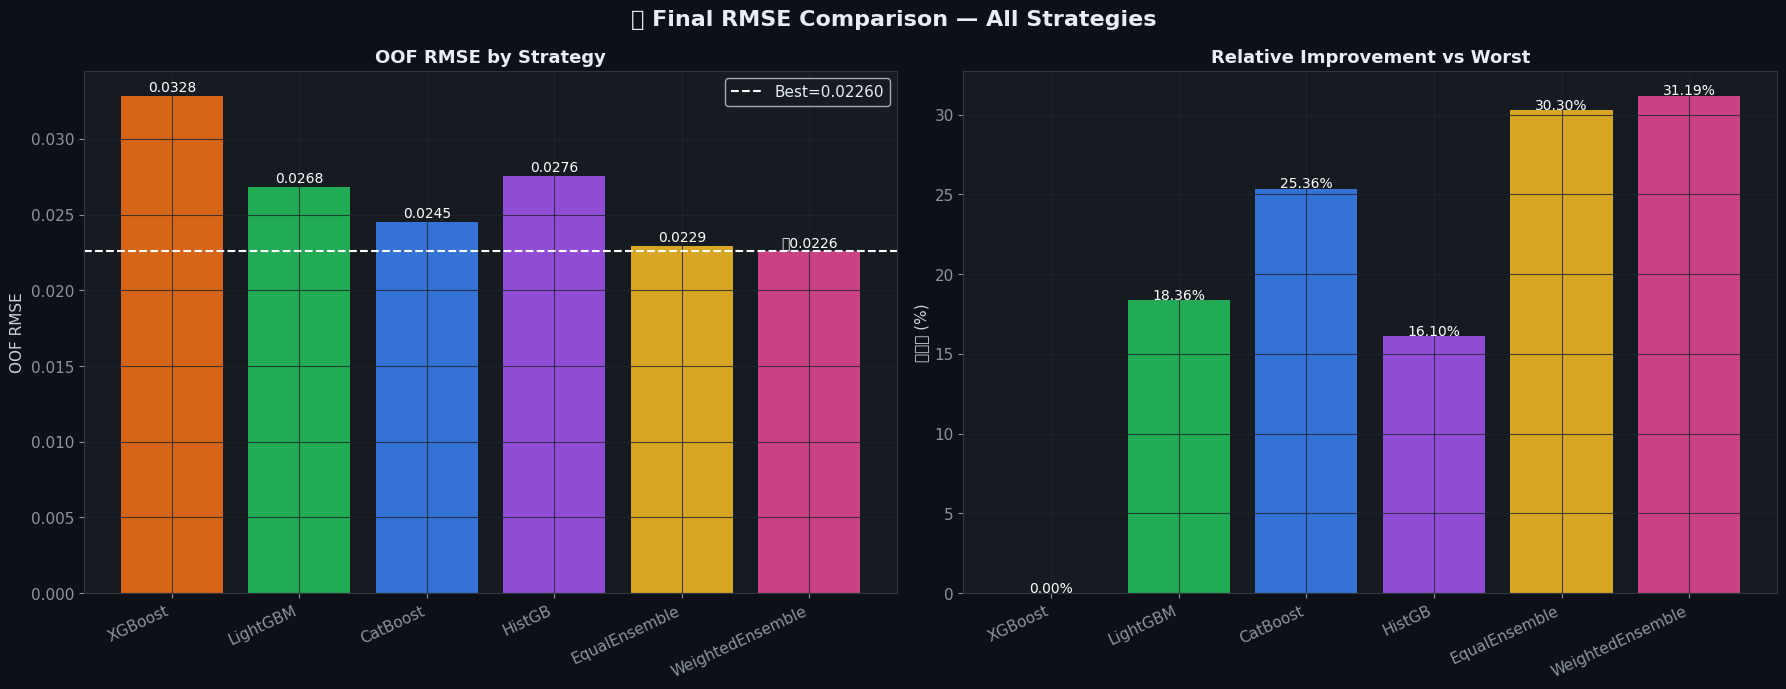

In [ ]:
# ─── 최종 RMSE 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('📊 Final RMSE Comparison — All Strategies')

all_names = list(all_rmses.keys())
all_vals  = list(all_rmses.values())
bar_colors = (
    [MODEL_COLORS.get(n, '#8b949e') for n in oof_rmses.keys()]
    + ['#fbbf24', '#a855f7', '#ec4899']  # Equal, Weighted, Optuna
)[:len(all_names)]

# RMSE 막대
bars = axes[0].bar(all_names, all_vals, color=bar_colors, alpha=0.85, edgecolor='none')
best_val = min(all_vals)
axes[0].axhline(best_val, color='white', ls='--', lw=1.5, label=f'Best={best_val:.5f}')
for bar, val, nm in zip(bars, all_vals, all_names):
    star = '⭐' if nm == best_strategy else ''
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.0003,
                 f'{star}{val:.4f}', ha='center', fontsize=10, color='white')
axes[0].set_ylabel('OOF RMSE')
axes[0].set_title('OOF RMSE by Strategy')
axes[0].legend()
axes[0].set_xticklabels(all_names, rotation=25, ha='right')

# 개선율
worst = max(all_vals)
improvements = [(worst - v) / worst * 100 for v in all_vals]
axes[1].bar(all_names, improvements, color=bar_colors, alpha=0.85, edgecolor='none')
for i, (nm, imp) in enumerate(zip(all_names, improvements)):
    axes[1].text(i, imp+0.05, f'{imp:.2f}%', ha='center', color='white', fontsize=10)
axes[1].set_ylabel('개선율 (%)')
axes[1].set_title('Relative Improvement vs Worst')
axes[1].set_xticklabels(all_names, rotation=25, ha='right')

plt.tight_layout()
plt.savefig('plot_12_final_rmse.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 💾 9. 제출 파일 생성 & 저장

In [ ]:
# ── 최적 전략 선택
if best_strategy in pred_dict:
    final_log = pred_dict[best_strategy]
elif best_strategy == 'OptEnsemble':
    final_log = opt_pred
elif best_strategy == 'EqualEnsemble':
    final_log = eq_pred
else:
    final_log = wtd_pred

print(f'사용 전략 : {best_strategy}')
print(f'OOF RMSE  : {all_rmses[best_strategy]:.5f}')

# ── 역변환 + 클리핑
final_pred = np.clip(np.expm1(final_log), CAL_MIN, CAL_MAX)

print(f'\n예측 통계 (클리핑 후):')
print(f'  min={final_pred.min():.2f}  max={final_pred.max():.2f}')
print(f'  mean={final_pred.mean():.2f}  median={np.median(final_pred):.2f}')

# ── Submission CSV
submission = pd.DataFrame({
    'ID'             : test_raw['ID'],
    'Calories_Burned': np.round(final_pred, 4)
})
submission.to_csv('submission.csv', index=False)
print('\n✅ submission.csv 저장 완료')
display(submission.head(10))

사용 전략 : WeightedEnsemble
OOF RMSE  : 0.02260

예측 통계 (클리핑 후):
  min=1.12  max=298.02
  mean=89.67  median=80.20

✅ submission.csv 저장 완료


,ID,Calories_Burned
0,TEST_0000,173.6751
1,TEST_0001,189.6373
2,TEST_0002,53.0423
3,TEST_0003,162.2627
4,TEST_0004,226.1494
5,TEST_0005,177.6274
6,TEST_0006,98.5489
7,TEST_0007,43.6563
8,TEST_0008,79.0474
9,TEST_0009,59.2681


In [ ]:
# ── OOF 전체 저장
oof_df = pd.DataFrame({'ID': train_raw['ID'],
                       'Actual': train_raw['Calories_Burned']})
for n, oof in oof_dict.items():
    oof_df[f'OOF_{n}'] = np.round(np.expm1(oof), 4)
oof_df['OOF_Equal']      = np.round(np.expm1(eq_oof), 4)
oof_df['OOF_Weighted']   = np.round(np.expm1(wtd_oof), 4)
oof_df['OOF_OptEnsemble']= np.round(np.expm1(opt_oof), 4)

oof_df.to_csv('oof_predictions.csv', index=False)
print('✅ oof_predictions.csv 저장 완료')
display(oof_df.head())

✅ oof_predictions.csv 저장 완료


,ID,Actual,OOF_XGBoost,OOF_LightGBM,OOF_CatBoost,OOF_HistGB,OOF_Equal,OOF_Weighted
0,TRAIN_0000,166.0,165.0675,166.5300,165.2437,167.5948,166.1059,166.1240
1,TRAIN_0001,33.0,33.8468,32.8022,32.8715,32.8794,33.0973,33.0583
2,TRAIN_0002,23.0,23.6544,23.0644,22.9737,22.7553,23.1097,23.0834
3,TRAIN_0003,91.0,91.5417,91.3505,91.4008,92.7233,91.7524,91.7472
4,TRAIN_0004,32.0,31.7114,32.2064,32.7836,32.4996,32.2979,32.3361


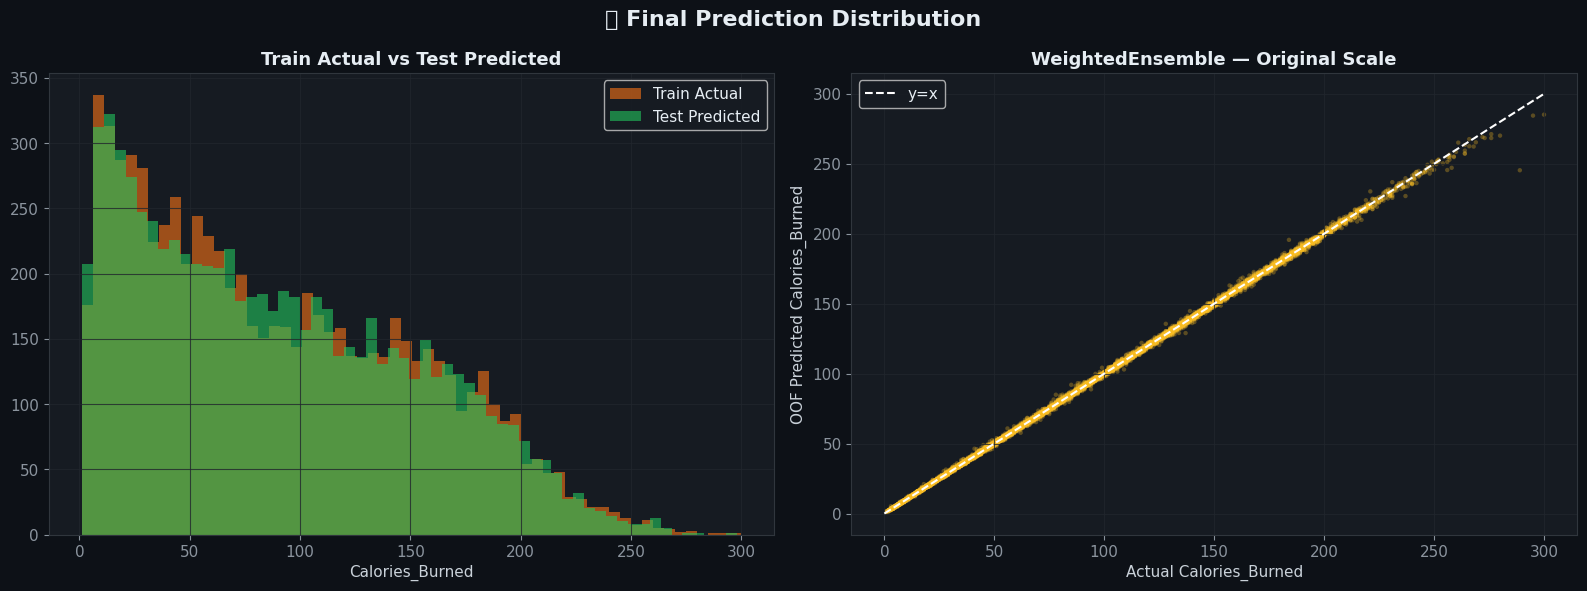

In [ ]:
# ── 예측 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('📊 Final Prediction Distribution')

# Train actual vs Test predicted
axes[0].hist(train_raw['Calories_Burned'], bins=60,
             alpha=0.6, color='#f97316', label='Train Actual', edgecolor='none')
axes[0].hist(final_pred, bins=60,
             alpha=0.6, color='#22c55e', label='Test Predicted', edgecolor='none')
axes[0].set_title('Train Actual vs Test Predicted')
axes[0].set_xlabel('Calories_Burned')
axes[0].legend()

# OOF 실제 vs 예측 (원본 스케일)
best_oof_orig = np.expm1(oof_dict[best_strategy]) if best_strategy in oof_dict \
                else np.expm1(eq_oof)
axes[1].scatter(train_raw['Calories_Burned'], best_oof_orig,
                alpha=0.3, s=10, color=MODEL_COLORS.get(best_strategy,'#fbbf24'),
                edgecolors='none')
lo, hi = 0, max(train_raw['Calories_Burned'].max(), best_oof_orig.max())
axes[1].plot([lo,hi],[lo,hi],'w--',lw=1.5,label='y=x')
axes[1].set_xlabel('Actual Calories_Burned')
axes[1].set_ylabel('OOF Predicted Calories_Burned')
axes[1].set_title(f'{best_strategy} — Original Scale')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_13_pred_dist.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 📋 10. 최종 요약

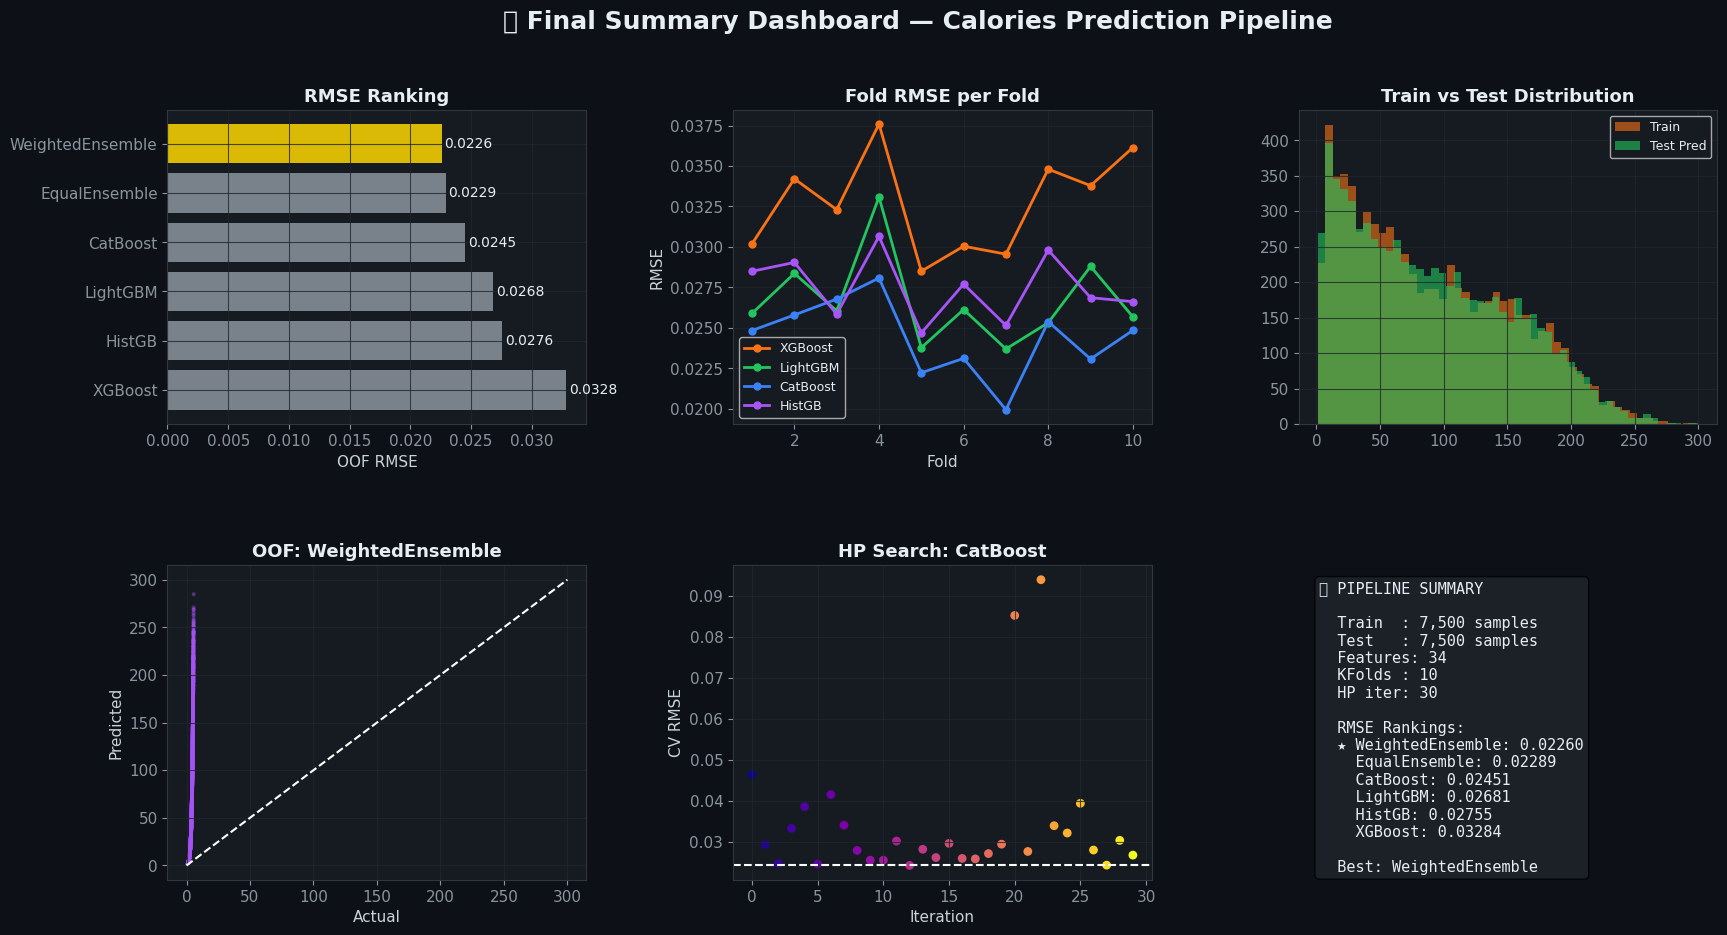

In [ ]:
# ─── Summary dashboard
fig = plt.figure(figsize=(20, 10))
fig.suptitle('🏁 Final Summary Dashboard — Optuna + XGB/LGB/CAT Ensemble', fontsize=18)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1) RMSE 랭킹
ax1 = fig.add_subplot(gs[0, 0])
sorted_names = sorted(all_rmses, key=all_rmses.get)
sorted_vals  = [all_rmses[n] for n in sorted_names]
bar_c = ['#ffd700' if n==best_strategy else '#8b949e' for n in sorted_names]
ax1.barh(sorted_names, sorted_vals, color=bar_c, alpha=0.85, edgecolor='none')
for i, (n, v) in enumerate(zip(sorted_names, sorted_vals)):
    ax1.text(v+0.0002, i, f'{v:.4f}', va='center', fontsize=10)
ax1.set_title('RMSE Ranking')
ax1.set_xlabel('OOF RMSE')
ax1.invert_yaxis()

# 2) Fold RMSE 라인
ax2 = fig.add_subplot(gs[0, 1])
for name, rmses in fold_rmse_dict.items():
    ax2.plot(np.arange(1,len(rmses)+1), rmses,
             marker='o', lw=2, ms=5, color=MODEL_COLORS[name], label=name)
ax2.set_title('Fold RMSE per Fold')
ax2.set_xlabel('Fold')
ax2.set_ylabel('RMSE')
ax2.legend(fontsize=9)

# 3) Prediction histogram
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(train_raw['Calories_Burned'], bins=50, alpha=0.6,
         color='#f97316', label='Train', edgecolor='none')
ax3.hist(final_pred, bins=50, alpha=0.6,
         color='#22c55e', label='Test Pred', edgecolor='none')
ax3.set_title('Train vs Test Distribution')
ax3.legend(fontsize=9)

# 4) Best model OOF scatter
ax4 = fig.add_subplot(gs[1, 0])
best_oof_orig = np.expm1(oof_dict[best_strategy]) if best_strategy in oof_dict \
                else np.expm1(opt_oof)
ax4.scatter(train_raw['Calories_Burned'], best_oof_orig,
            alpha=0.25, s=8, color='#a855f7', edgecolors='none')
lo2, hi2 = 0, train_raw['Calories_Burned'].max()
ax4.plot([lo2,hi2],[lo2,hi2],'w--',lw=1.5)
ax4.set_title(f'OOF: {best_strategy}')
ax4.set_xlabel('Actual'); ax4.set_ylabel('Predicted')

# 5) Optuna 탐색 히스토리 — 최고 모델 기준
ax5 = fig.add_subplot(gs[1, 1])
bm = sorted(oof_rmses, key=oof_rmses.get)[0]
bm_study = studies[bm]
bm_df = bm_study.trials_dataframe()
bm_completed = bm_df[bm_df['state']=='COMPLETE'].sort_values('number')
ax5.scatter(bm_completed['number'], bm_completed['value'],
            c=range(len(bm_completed)), cmap='plasma', s=40, edgecolors='none')
ax5.plot(bm_completed['number'], bm_completed['value'].cummin(),
         color='white', lw=2)
ax5.axhline(bm_study.best_value, color='gold', ls='--', lw=1.5)
ax5.set_title(f'Optuna History: {bm}')
ax5.set_xlabel('Trial'); ax5.set_ylabel('CV RMSE')

# 6) 텍스트 요약
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
lines = [
    '📊 PIPELINE SUMMARY',
    '',
    f'  Train  : {len(train_raw):,} samples',
    f'  Test   : {len(test_raw):,} samples',
    f'  Features: {len(FEATURES)}',
    f'  KFolds : {FOLDS}',
    f'  Optuna : {N_TRIALS} trials/model',
    '',
    '  RMSE Rankings:',
]
for k in sorted(all_rmses, key=all_rmses.get):
    lines.append(f'  {"★" if k==best_strategy else " "} {k}: {all_rmses[k]:.5f}')
lines += ['', f'  Best: {best_strategy}']
ax6.text(0.05, 0.95, '\n'.join(lines), transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', family='monospace',
         color='#e6edf3',
         bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))

plt.savefig('plot_14_dashboard.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [ ]:
# ─── 전체 결과 RMSE CSV 저장
results_df = pd.DataFrame([
    {'Strategy': k, 'OOF_RMSE': round(v, 6), 'Is_Best': k==best_strategy}
    for k, v in sorted(all_rmses.items(), key=lambda x: x[1])
])
results_df.to_csv('rmse_results.csv', index=False)
print('✅ rmse_results.csv 저장 완료')
display(results_df)

print('\n' + '='*60)
print('  📂 생성된 파일 목록')
print('='*60)
files_list = [
    'submission.csv         → 최종 테스트 예측 (제출용)',
    'oof_predictions.csv    → OOF 예측 전체 (검증용)',
    'rmse_results.csv       → 모델별 RMSE 결과',
    'best_params_optuna.csv → Optuna 최적 하이퍼파라미터',
    'plot_06_optuna_history.png → Optuna 탐색 시각화',
    'plot_12_final_rmse.png → 최종 RMSE 비교',
    'plot_14_dashboard.png  → 종합 대시보드',
]
for f in files_list:
    print(f'  {f}')

✅ rmse_results.csv 저장 완료


,Strategy,OOF_RMSE,Is_Best
0,WeightedEnsemble,0.022598,True
1,EqualEnsemble,0.022891,False
2,CatBoost,0.024515,False
3,LightGBM,0.026813,False
4,HistGB,0.027554,False
5,XGBoost,0.032842,False



  📂 생성된 파일 목록
  submission.csv            → 최종 테스트 예측 (제출용)
  oof_predictions.csv       → OOF 예측 (검증용)
  rmse_results.csv          → 모델별 RMSE 결과
  best_hyperparameters.csv  → 최적 하이퍼파라미터
  plot_01_target_dist.png   → 타겟 분포
  plot_02_num_distributions.png → 수치형 피처 분포
  plot_03_categorical.png   → 범주형 분석
  plot_04_scatter.png       → 피처 vs 타겟
  plot_05_heatmap.png       → 상관관계 히트맵
  plot_06_feature_corr.png  → 엔지니어링 후 상관관계
  plot_07_hp_search.png     → 하이퍼파라미터 탐색
  plot_08_fold_rmse.png     → Fold별 RMSE
  plot_09_oof_scatter.png   → OOF 산점도
  plot_10_residuals.png     → 잔차 분석
  plot_11_feature_importance.png → 피처 중요도
  plot_12_final_rmse.png    → 최종 RMSE 비교
  plot_13_pred_dist.png     → 예측 분포
  plot_14_dashboard.png     → 종합 대시보드


In [ ]:
# Colab에서 파일 다운로드
try:
    from google.colab import files
    for fname in ['submission.csv','oof_predictions.csv',
                  'rmse_results.csv','best_params_optuna.csv']:
        files.download(fname)
    print('✅ 파일 다운로드 시작됨')
except ImportError:
    print('ℹ️  Colab 외 환경 — 파일은 현재 디렉토리에 저장됨')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 파일 다운로드 시작됨
